### Import Libraries

In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error, max_error
from scipy.stats import median_abs_deviation
from tabulate import tabulate
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import VarianceThreshold

### Load the Datasets

In [56]:
#combined_df = pd.read_csv('combined_Octoparse_categorized.csv')
combined_df = pd.read_csv('../../Cleaned Data/Cleaned_Data_LastVersion.csv')
target_variable = 'Number of Reviewers'
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1854 entries, 0 to 1853
Data columns (total 48 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Business ID                               1854 non-null   object 
 1   Name                                      1854 non-null   object 
 2   Latitude                                  1854 non-null   float64
 3   Longitude                                 1854 non-null   float64
 4   Category                                  1854 non-null   object 
 5   Rating                                    1854 non-null   object 
 6   Popularity                                1854 non-null   float64
 7   Google Place ID                           1854 non-null   object 
 8   Business Status                           1854 non-null   object 
 9   Distance (m)                              1854 non-null   float64
 10  Cluster                             

## Data Pre-processing

In [40]:
pd.set_option('display.max_columns', None)
#combined_df[combined_df['Indirect Competition - Food & Dining/POI Density'].isnull()]

### Drop Irrelevent columns

In [57]:
# Drop irrelevant columns
"""
drop_columns = ['Address', 'Country', 'State', 'City', 'Category', 'Price_Range', 
                'Current_Status', 'Title', 'Rating', 'Google_id',
                'Latitude', 'Longitude', 'Religious Institutions', 'Health', 
                'Public & Government Services', 'Entertainment & Recreation', 'Transportation & Travel',
                'Finance & Services', 'Retail & Shopping', 'Home & Construction Services', 'Beauty & Wellness',
                'Hotels & Hospitality', 'Education'
               ]
"""
# Drop irrelevant columns
drop_columns = ['Business ID', 'Latitude'	, 'Longitude', 'Name', 'Category', 'Rating', 'Google Place ID', 'Business Status',
                'Cluster', 'Distance (m)', 'Avg Rating - Business Type', 'Competition - Business Type/Area', 'Competition - Food & Dining/Area',
                'Competition - Business Type/POI Density', 'Competition - Food & Dining/related POIs', 'Competition - Business Type/related POIs'
               , 'Google Rating', 'Business Name', 'District']

combined_df.drop(columns=drop_columns, inplace=True, errors='ignore')


In [42]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1863 entries, 0 to 1862
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Popularity                               1863 non-null   float64
 1   generalCategory                          1863 non-null   int64  
 2   Religious Institutions                   1863 non-null   int64  
 3   Coffee Shops                             1863 non-null   int64  
 4   Food & Dining                            1863 non-null   int64  
 5   Restaurants                              1863 non-null   int64  
 6   Home & Construction Services             1863 non-null   int64  
 7   Entertainment & Recreation               1863 non-null   int64  
 8   Retail & Shopping                        1863 non-null   int64  
 9   Finance & Services                       1863 non-null   int64  
 10  Education                                1863 no

### Drop Rows with missing #of Reviewrs

In [58]:
# Ensure that the 'Number of Reviewers' column is numeric and handle errors as NaN
combined_df[target_variable] = pd.to_numeric(combined_df[target_variable], errors='coerce')

# Drop rows where 'Number of Reviewers' is NaN (if you want to ignore them in analysis)
combined_df = combined_df.dropna(subset=[target_variable])

In [44]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1861 entries, 0 to 1862
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Popularity                               1861 non-null   float64
 1   generalCategory                          1861 non-null   int64  
 2   Religious Institutions                   1861 non-null   int64  
 3   Coffee Shops                             1861 non-null   int64  
 4   Food & Dining                            1861 non-null   int64  
 5   Restaurants                              1861 non-null   int64  
 6   Home & Construction Services             1861 non-null   int64  
 7   Entertainment & Recreation               1861 non-null   int64  
 8   Retail & Shopping                        1861 non-null   int64  
 9   Finance & Services                       1861 non-null   int64  
 10  Education                                1861 non-nul

### Find Null values

In [45]:
print(combined_df.isnull().sum())

Popularity                                  0
generalCategory                             0
Religious Institutions                      0
Coffee Shops                                0
Food & Dining                               0
Restaurants                                 0
Home & Construction Services                0
Entertainment & Recreation                  0
Retail & Shopping                           0
Finance & Services                          0
Education                                   0
Health                                      0
Public & Government Services                0
Hotels & Hospitality                        0
Transportation & Travel                     0
Beauty & Wellness                           0
POI Density                                 0
Avg Rating - Food & Dining                 15
Competition - Food & Dining/POI Density     0
Population Within 1km                       0
Number of Reviewers                         0
Avg_NumOfReviewers - Food & Dining

### Fill Missing Values with median

In [59]:
#Fill missing values using median of the specfic food-chain

combined_df["Avg Rating - Food & Dining"] = combined_df["Avg Rating - Food & Dining"].fillna(combined_df["Avg Rating - Food & Dining"].median())
combined_df["Avg_NumOfReviewers - Food & Dining"] = combined_df["Avg_NumOfReviewers - Food & Dining"].fillna(combined_df["Avg_NumOfReviewers - Food & Dining"].median())
combined_df["Avg_NumOfReviewers_SameCategory"] = combined_df["Avg_NumOfReviewers_SameCategory"].fillna(combined_df["Avg_NumOfReviewers_SameCategory"].median())
combined_df["Total Num of Reviewers - Food & Dining"] = combined_df["Total Num of Reviewers - Food & Dining"].fillna(combined_df["Total Num of Reviewers - Food & Dining"].median())
combined_df["Number of Reviewers"] = combined_df["Number of Reviewers"].fillna(
    combined_df.groupby("generalCategory")["Number of Reviewers"].transform("median")
)

print(combined_df.isnull().sum())

Popularity                                 0
generalCategory                            0
Religious Institutions                     0
Coffee Shops                               0
Food & Dining                              0
Restaurants                                0
Home & Construction Services               0
Entertainment & Recreation                 0
Retail & Shopping                          0
Finance & Services                         0
Education                                  0
Health                                     0
Public & Government Services               0
Hotels & Hospitality                       0
Transportation & Travel                    0
Beauty & Wellness                          0
POI Density                                0
Avg Rating - Food & Dining                 0
Competition - Food & Dining/POI Density    0
Population Within 1km                      0
Number of Reviewers                        0
Avg_NumOfReviewers - Food & Dining         0
Avg_NumOfR

In [ ]:
#combined_df['general_category'] = (combined_df['keyword'] != 'Coffee shop').astype(int)
combined_df

### Helper Functions (Highly Correlated Features, Outliers)

In [32]:
# Helper Functions to remove outliers and highly correlated features

def remove_outliers(X, y):
    """Remove outliers using IQR."""
    Q1 = np.percentile(y, 25)
    Q3 = np.percentile(y, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    mask = (y >= lower_bound) & (y <= upper_bound)
    return X[mask], y[mask]

    
# Remove Highly Correlated Features (Modified)
removed_corr_features = []  # List to store removed features

def remove_highly_correlated_features(X, threshold=0.9):
    """Removes highly correlated features from X."""
    corr_matrix = X.corr().abs()  # Compute absolute correlation matrix
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))  # Upper triangle

    # Find columns to drop
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > threshold)]
    return X.drop(columns=to_drop, errors='ignore'), to_drop  # Drop and return removed features

### Visualization of Data Distribution

KeyboardInterrupt: 

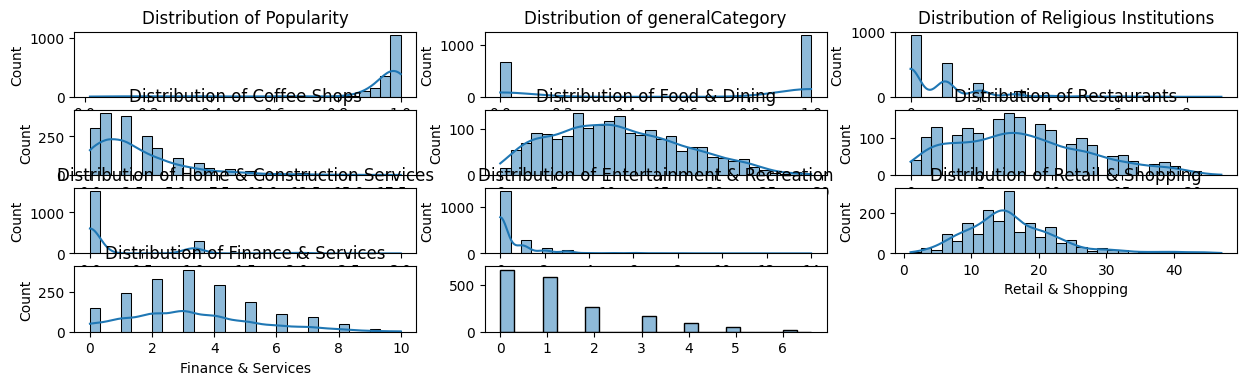

In [397]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot the distribution of all features in a DataFrame
def plot_feature_distributions(df):
    num_cols = df.select_dtypes(include=['number']).columns  # Select only numeric columns
    
    plt.figure(figsize=(15, 10))
    
    for i, col in enumerate(num_cols, 1):
        plt.subplot((len(num_cols) // 3) + 1, 3, i)  # Create subplots with 3 columns
        sns.histplot(df[col], kde=True, bins=30)  # Histogram with KDE
        plt.title(f'Distribution of {col}')
    
    plt.tight_layout()
    plt.show()

# Call the function with your dataframe
plot_feature_distributions(combined_df)


### Outliers Detection

In [48]:
# Select only numeric columns, excluding "Number of Reviews"
numeric_features = combined_df.select_dtypes(include=[np.number]).columns
#features = [col for col in numeric_features if col != "Review_Count"]

features = [col for col in numeric_features if col != target_variable]

# Function to detect outliers using IQR and count records with any outlier
def detect_outliers_iqr(df, features):
    outlier_counts = {}
    outlier_mask = np.zeros(df.shape[0], dtype=bool)  # Boolean mask to track rows with outliers

    for feature in features:
        Q1 = df[feature].quantile(0.25)  # First quartile
        Q3 = df[feature].quantile(0.75)  # Third quartile
        IQR = Q3 - Q1  # Interquartile Range
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Create a mask for outliers in this feature
        feature_outliers = (df[feature] < lower_bound) | (df[feature] > upper_bound)
        outlier_counts[feature] = feature_outliers.sum()  # Count outliers per feature
        outlier_mask |= feature_outliers  # Combine with the overall mask

    # Count records that contain at least one outlier
    num_records_with_outliers = np.sum(outlier_mask)
    
    return outlier_counts, num_records_with_outliers

# Detect outliers
outlier_results, num_outlier_records = detect_outliers_iqr(combined_df, features)

# Print the number of outliers for each feature
print("Outlier Counts Per Feature:")
for feature, count in outlier_results.items():
    print(f"{feature}: {count} outliers")

# Print the number of records that contain at least one outlier
print(f"\nNumber of records containing at least one outlier: {num_outlier_records}")


Outlier Counts Per Feature:
Popularity: 186 outliers
generalCategory: 0 outliers
Religious Institutions: 160 outliers
Coffee Shops: 80 outliers
Food & Dining: 1 outliers
Restaurants: 1 outliers
Home & Construction Services: 345 outliers
Entertainment & Recreation: 143 outliers
Retail & Shopping: 66 outliers
Finance & Services: 70 outliers
Education: 41 outliers
Health: 36 outliers
Public & Government Services: 98 outliers
Hotels & Hospitality: 138 outliers
Transportation & Travel: 91 outliers
Beauty & Wellness: 75 outliers
POI Density: 717 outliers
Avg Rating - Food & Dining: 44 outliers
Competition - Food & Dining/POI Density: 1 outliers
Population Within 1km: 148 outliers
Avg_NumOfReviewers - Food & Dining: 116 outliers
Avg_NumOfReviewers_SameCategory: 108 outliers
Population Within 2km: 69 outliers
Population Within 3km: 0 outliers
Total Num of Reviewers - Food & Dining: 46 outliers
Total Num of Reviewers - All POIs: 51 outliers
Residential Average Price: 89 outliers

Number of reco

### Data Transformation

In [ ]:
# Data Transformation and Scaling with QuantileTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import shapiro, probplot
from sklearn.preprocessing import QuantileTransformer, MinMaxScaler

# Copy DataFrame
transformed_df = combined_df.copy()

# Remove outliers in 'Popularity' using IQR method
# Q1 = transformed_df['Popularity'].quantile(0.25)
# Q3 = transformed_df['Popularity'].quantile(0.75)
# IQR = Q3 - Q1
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR
# transformed_df = transformed_df[(transformed_df['Popularity'] >= lower_bound) & (transformed_df['Popularity'] <= upper_bound)]

transformed_df.info()

# Select numerical columns
num_cols = transformed_df.select_dtypes(include=['number']).columns

# Store original distributions before transformation
original_distributions = transformed_df[num_cols].copy()

# Apply QuantileTransformer (normalize distribution)
quantile_transformer = QuantileTransformer(output_distribution='normal', random_state=42)  
# output_distribution='normal' ensures normal-like distribution
transformed_df[num_cols] = quantile_transformer.fit_transform(transformed_df[num_cols])

# Apply MinMaxScaler (scale to 0-1)
#minmax_scaler = MinMaxScaler()
#transformed_df[num_cols] = minmax_scaler.fit_transform(transformed_df[num_cols])

# Plot before and after transformation distributions
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(12, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    # Original distribution
    sns.histplot(original_distributions[col], kde=True, bins=30, ax=axes[i, 0])
    axes[i, 0].set_title(f'Original Distribution: {col}')
    
    # Transformed distribution
    sns.histplot(transformed_df[col], kde=True, bins=30, ax=axes[i, 1], color='purple')
    axes[i, 1].set_title(f'Transformed Distribution: {col}')

plt.tight_layout()
plt.show()


transformed_df


In [ ]:
#Data Transformation and Scaling
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import shapiro, probplot
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
"""
# Copy DataFrame
transformed_df = combined_df.copy()

# Remove outliers in 'Popularity' using IQR method
#Q1 = transformed_df['Popularity'].quantile(0.25)
#Q3 = transformed_df['Popularity'].quantile(0.75)
#IQR = Q3 - Q1
#lower_bound = Q1 - 1.5 * IQR
#upper_bound = Q3 + 1.5 * IQR
#transformed_df = transformed_df[(transformed_df['Popularity'] >= lower_bound) & (transformed_df['Popularity'] <= upper_bound)]

transformed_df.info()
# Select numerical columns
num_cols = transformed_df.select_dtypes(include=['number']).columns

# Store original distributions before transformation
original_distributions = transformed_df[num_cols].copy()

# Apply PowerTransformer (normalize distribution)
power_transformer = PowerTransformer()
transformed_df[num_cols] = power_transformer.fit_transform(transformed_df[num_cols])

# Apply MinMaxScaler (scale to 0-1)
minmax_scaler = MinMaxScaler()
transformed_df[num_cols] = minmax_scaler.fit_transform(transformed_df[num_cols])

# Plot before and after transformation distributions
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(12, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    # Original distribution
    sns.histplot(original_distributions[col], kde=True, bins=30, ax=axes[i, 0])
    axes[i, 0].set_title(f'Original Distribution: {col}')
    
    # Transformed distribution
    sns.histplot(transformed_df[col], kde=True, bins=30, ax=axes[i, 1], color='purple')
    axes[i, 1].set_title(f'Transformed Distribution: {col}')

plt.tight_layout()
plt.show()

# Perform Shapiro-Wilk test for normality on each transformed feature
normality_results = {}
for col in num_cols:
    shapiro_test_stat, shapiro_p_value = shapiro(transformed_df[col])
    normality_results[col] = {
        "Shapiro-Wilk Test Statistic": shapiro_test_stat,
        "p-value": shapiro_p_value,
        "Normality": "Yes" if shapiro_p_value > 0.05 else "No"
    }

# Convert results to DataFrame
normality_df = pd.DataFrame(normality_results).T

# Display normality test results
#print("\nShapiro-Wilk Normality Test Results:")
#print(normality_df)

# Optionally, save results to a CSV file
#normality_df.to_csv("normality_test_results.csv", index=True)

# Q-Q Plots for each transformed feature
#fig, axes = plt.subplots(nrows=len(num_cols), figsize=(6, len(num_cols) * 3))

#for i, col in enumerate(num_cols):
#    probplot(transformed_df[col], dist="norm", plot=axes[i])
#    axes[i].set_title(f"Q-Q Plot: {col}")

#plt.tight_layout()
#plt.show()
transformed_df
"""

In [ ]:
# Select only numeric columns, excluding "Number of Reviews"
numeric_features = combined_df.select_dtypes(include=[np.number]).columns
#features = [col for col in numeric_features if col != "Review_Count"]

features = [col for col in numeric_features if col != target_variable]

# Function to detect outliers using IQR and count records with any outlier
def detect_outliers_iqr(df, features):
    outlier_counts = {}
    outlier_mask = np.zeros(df.shape[0], dtype=bool)  # Boolean mask to track rows with outliers

    for feature in features:
        Q1 = df[feature].quantile(0.25)  # First quartile
        Q3 = df[feature].quantile(0.75)  # Third quartile
        IQR = Q3 - Q1  # Interquartile Range
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Create a mask for outliers in this feature
        feature_outliers = (df[feature] < lower_bound) | (df[feature] > upper_bound)
        outlier_counts[feature] = feature_outliers.sum()  # Count outliers per feature
        outlier_mask |= feature_outliers  # Combine with the overall mask

    # Count records that contain at least one outlier
    num_records_with_outliers = np.sum(outlier_mask)
    
    return outlier_counts, num_records_with_outliers

# Detect outliers
outlier_results, num_outlier_records = detect_outliers_iqr(combined_df, features)

# Print the number of outliers for each feature
print("Outlier Counts Per Feature:")
for feature, count in outlier_results.items():
    print(f"{feature}: {count} outliers")

# Print the number of records that contain at least one outlier
print(f"\nNumber of records containing at least one outlier: {num_outlier_records}")

## Dataset Splitting

In [60]:
# Separate based on 'general_category'
"""
coffee_df = combined_df[combined_df['general_category'] == 0].reset_index(drop=True)
restaurant_df = combined_df[combined_df['general_category'] == 1].reset_index(drop=True)
"""

coffee_df = combined_df[combined_df['generalCategory'] == 0].reset_index(drop=True)
restaurant_df = combined_df[combined_df['generalCategory'] == 1].reset_index(drop=True)

# Optional: print shapes to confirm
print(f"Coffee Shops: {coffee_df.shape[0]} rows")
print(f"Restaurants: {restaurant_df.shape[0]} rows")

# --- Training and Testing ----

# Split combined_df into 80% train and 20% test
combined_df_train, combined_df_test = train_test_split(
    combined_df,
    test_size=0.2,
    random_state=42,  # for reproducibility
    shuffle=True      # ensure data is shuffled before splitting
)

# Optional: Print shape summary
print(f"Train set size: {combined_df_train.shape[0]}")
print(f"Test set size: {combined_df_test.shape[0]}")

combined_df_test.head()

# Define test keywords - Using specific food-chain
#test_coffee_keyword = "Dunkin"
#test_restaurant_keyword = "McDonald's"

# Coffee: train/test split
#coffee_test = combined_df[combined_df['Place_id'].isin(filtered_coffee['Place_id'])].reset_index(drop=True)
#coffee_train = combined_df[~combined_df['Place_id'].isin(filtered_coffee['Place_id'])].reset_index(drop=True)


# Restaurant: train/test split
#restaurant_test = combined_df[combined_df['Place_id'].isin(filtered_restaurants['Place_id'])].reset_index(drop=True)
#restaurant_train = combined_df[~combined_df['Place_id'].isin(filtered_restaurants['Place_id'])].reset_index(drop=True)

# Print results
#print("Coffee - Train:", coffee_train.shape[0], "Test:", coffee_test.shape[0])
#print("Restaurant - Train:", restaurant_train.shape[0], "Test:", restaurant_test.shape[0])


Coffee Shops: 667 rows
Restaurants: 1185 rows
Train set size: 1481
Test set size: 371


,Popularity,generalCategory,Religious Institutions,Coffee Shops,Food & Dining,Restaurants,Home & Construction Services,Entertainment & Recreation,Retail & Shopping,Finance & Services,...,Population Within 1km,Number of Reviewers,Avg_NumOfReviewers - Food & Dining,Avg_NumOfReviewers_SameCategory,Population Within 2km,Population Within 3km,Total Num of Reviewers - Food & Dining,Total Num of Reviewers - All POIs,Residential Average Price,Avg Num of Reviewers - All POIs
233,0.999969,0,1,8,13,7,0,0,13,1,...,20369,3275.0,920.0,1177.0,45365,91266,12056.0,17918,27340.0,333.509434
450,0.962244,0,0,0,1,1,0,0,20,3,...,45540,366.0,2364.0,744.0,135145,264062,2364.0,18802,16229.0,329.736842
1241,0.999555,1,0,1,16,14,0,1,18,5,...,49807,1854.0,930.0,995.0,129578,216901,14943.0,23399,17017.0,454.627451
1695,0.968588,1,2,2,2,0,0,0,8,4,...,26434,377.0,3597.0,744.0,72097,167152,7195.0,75919,32904.0,1308.948276
411,0.959842,0,5,3,5,2,1,2,12,2,...,49563,1085.0,1808.0,717.0,139122,317088,9040.0,22631,15122.0,410.236364


## Features Analyses 

### Pearson correlation

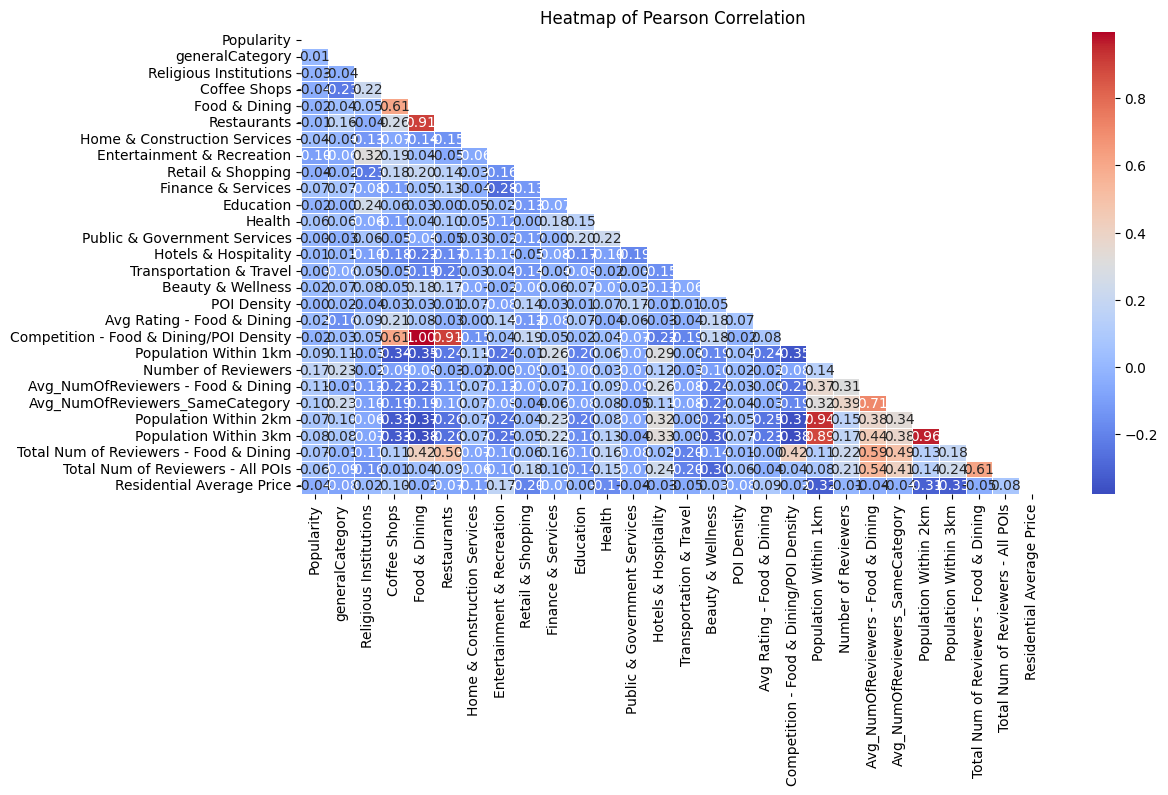

In [50]:
# Compute Pearson correlation

corr_matrix = combined_df.select_dtypes(include=['number']).corr()

# Create a mask for the upper triangular part
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Heatmap of Pearson Correlation")
plt.show()


### Scatterplots

In [ ]:
# Original Dataframe (WITHOUT transformation)
# Filter only numeric features (excluding target variable "Number of Reviewers")
numeric_features = combined_df.select_dtypes(include=np.number).columns
features_to_plot = [feature for feature in numeric_features if feature != target_variable]

# Define grid size
num_features = len(features_to_plot)
num_cols = 3  # Number of columns in the grid
num_rows = (num_features // num_cols) + (num_features % num_cols > 0)  # Compute required rows

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 4))
axes = axes.flatten()  # Flatten the 2D array of axes for easy indexing

# Loop through features and create scatter plots
for i, feature in enumerate(features_to_plot):
    sns.scatterplot(x=combined_df[feature], y=combined_df[target_variable], alpha=0.6, ax=axes[i])
    axes[i].set_xlabel(feature, fontsize=10)
    axes[i].set_ylabel(target_variable, fontsize=10)
    axes[i].set_title(f"{feature} vs. Popularity", fontsize=12)
    axes[i].grid(True, linestyle="--", alpha=0.5)

# Remove empty subplots if num_features < num_cols*num_rows
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])  # Remove unused subplots

# Adjust layout
plt.tight_layout()
plt.show()


# Experiment 1: 80% - 20% dataset

### X and y Variables

In [174]:
# -----------------------------
# Step 1: Define features and target
# -----------------------------

# Columns to drop
"""
columns_to_drop = [
    'Review_Count', 'keyword', 'Place_id', 'Indirect Competition - Food & Dining/POI Density', 
    'Population_Within_2km', 'Population_Within_1km',
    'Religious Institutions', 'Public & Government Services', 'Health',
    'Home & Construction Services', 'Education', 'Avg Rating - Restaurants', 'Avg_NumOfReviewers - Food & Dining', 'Avg_NumOfReviewers_SameCategory',
    'Avg Rating - Coffee Shops', 'Avg Num of Reviewers - Restaurants',
    'Avg Num of Reviewers - Coffee Shops',
    'Hotels & Hospitality', 'Finance & Services', 'Transportation & Travel',
    'Restaurants', 'Coffee Shops', 'Food & Dining', 'Total Num of Reviewers - Food & Dining
]
"""

columns_to_drop = [target_variable, 'Total Num of Reviewers - Food & Dining', 'Total Num of Reviewers - All POIs', 'Avg_NumOfReviewers - Food & Dining','Avg_NumOfReviewers_SameCategory', 'Total Num of Reviewers - Food & Dining','Population Within 1km', 'Population Within 2km', 'Popularity', 
                   'Home & Construction Services', 'Public & Government Services','Religious Institutions', 'Education' , 'POI Density', 'Health',
                    'Entertainment & Recreation']
#'Total Num of Reviewers - All POIs'
#training 
X_train = combined_df_train.drop(columns=columns_to_drop, errors='ignore')
y_train = combined_df_train[target_variable]

#testing
X_test = combined_df_test.drop(columns=columns_to_drop, errors='ignore')
y_test = combined_df_test[target_variable].values

# Optional: Print shape summary
print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")



Train set size: 1481
Test set size: 371


### Remove Highly Correlated features

In [175]:
# -----------------------------
# Step 2: Remove highly correlated features
# -----------------------------

def remove_highly_correlated_features(df, threshold=0.95):
    corr_matrix = df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return df.drop(columns=to_drop), to_drop

X_train, removed_corr_features = remove_highly_correlated_features(X_train, threshold=0.95)
X_columns = X_train.columns
X_test = X_test[X_columns]

print(f"Removed highly correlated features: {removed_corr_features}")


Removed highly correlated features: ['Competition - Food & Dining/POI Density']


In [176]:
X_train.columns

Index(['generalCategory', 'Coffee Shops', 'Food & Dining', 'Restaurants', 'Retail & Shopping', 'Finance & Services', 'Hotels & Hospitality', 'Transportation & Travel', 'Beauty & Wellness', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price', 'Avg Num of Reviewers - All POIs'], dtype='object')

### Transformation and Scaling

In [177]:
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# Initialize PowerTransformer for X
pt = PowerTransformer(method='yeo-johnson', standardize=False)  # Set standardize=False since we'll use MinMaxScaler next
scaler = MinMaxScaler()

# Fit on train and apply to both train and test
X_train_transformed = scaler.fit_transform(pt.fit_transform(X_train))
X_test_transformed = scaler.transform(pt.transform(X_test))

# Reshape y to 2D arrays (required by sklearn scalers)
y_train_reshaped = y_train.values.reshape(-1, 1)
y_test_reshaped = y_test.reshape(-1, 1)

# Initialize separate transformers for y
pt_y = PowerTransformer(method='yeo-johnson', standardize=False)
scaler_y = MinMaxScaler()

# Fit on training target and transform both y_train and y_test
y_train_transformed = scaler_y.fit_transform(pt_y.fit_transform(y_train_reshaped)).ravel()
y_test_transformed = scaler_y.transform(pt_y.transform(y_test_reshaped)).ravel()


In [81]:
# Ensure all columns and full content are displayed
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)  # Show full content of each cell
pd.set_option('display.width', 1000)

## Random Forest

In [181]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.metrics import ndcg_score



# -----------------------------
# Step 4: Grid Search - Random Forest
# -----------------------------

rf_model = RandomForestRegressor(random_state= None, n_estimators = 100, max_depth = 10, min_samples_split = 5, min_samples_leaf = 4, max_features = "log2")

param_grid = {"n_estimators": [100],
              "max_depth": [10],
              "min_samples_split": [5],
              "min_samples_leaf": [4],
              "max_features": ["log2"]}

#grid_search = GridSearchCV(rf_model, param_grid, scoring='r2', verbose=1, n_jobs=-1)
rf_model.fit(X_train_transformed, y_train_transformed)

y_pred = rf_model.predict(X_test_transformed)


# y_pred is your model's prediction (on transformed scale)
# reshape to 2D for inverse_transform and overwrite y_pred 
#y_pred = pt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()


# -----------------------------
# Step 5: Evaluate - Regression Metrics
# -----------------------------

r2 = r2_score(y_test_transformed, y_pred)
mse = mean_squared_error(y_test_transformed, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_transformed, y_pred)

# -----------------------------
# Step 6: Evaluate - Ranking Metrics
# -----------------------------

k = 10
true_ranks = y_test_transformed.argsort()[::-1]
pred_ranks = y_pred.argsort()[::-1]

true_relevance = np.expand_dims(y_test_transformed, axis=0)
predicted_scores = np.expand_dims(y_pred, axis=0)

ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

top_k_true = set(true_ranks[:k])
top_k_pred = set(pred_ranks[:k])
nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

# -----------------------------
# Step 7: Results
# -----------------------------

print("\n--- Best Model Parameters ---")
#print(grid_search.best_params_)

print("\n--- Regression Metrics ---")
print(f"R² Score:   {r2:.3f}")
print(f"MSE:        {mse:.3f}")
print(f"RMSE:       {rmse:.3f}")
print(f"MAE:        {mae:.3f}")

print("\n--- Ranking Metrics ---")
print(f"nDCG@{k}:   {ndcg:.3f}")
print(f"nSD@{k}:    {nSD:.3f}")



--- Best Model Parameters ---

--- Regression Metrics ---
R² Score:   0.253
MSE:        0.020
RMSE:       0.143
MAE:        0.113

--- Ranking Metrics ---
nDCG@10:   0.773
nSD@10:    0.800


#### Features Importance

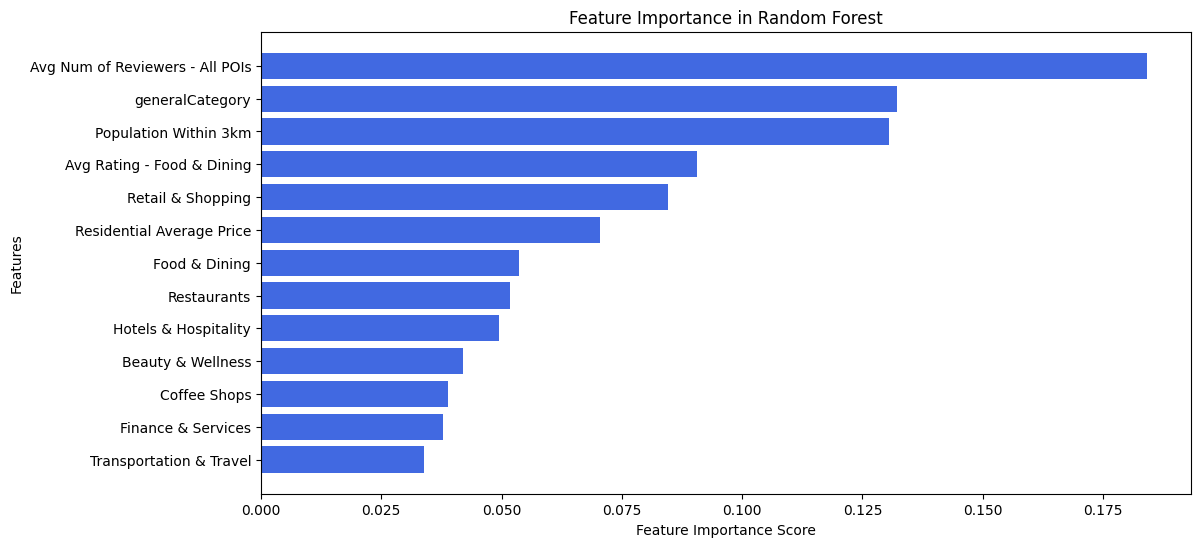


Feature Importance Scores:
                            Feature  Importance
12  Avg Num of Reviewers - All POIs    0.184041
0                   generalCategory    0.132158
10            Population Within 3km    0.130601
9        Avg Rating - Food & Dining    0.090652
4                 Retail & Shopping    0.084631
11        Residential Average Price    0.070405
2                     Food & Dining    0.053633
3                       Restaurants    0.051788
6              Hotels & Hospitality    0.049430
8                 Beauty & Wellness    0.042054
1                      Coffee Shops    0.038876
5                Finance & Services    0.037821
7           Transportation & Travel    0.033908


In [182]:
# Compute feature importance from the best estimator

feature_importance = rf_model.feature_importances_

# Create DataFrame for feature importance
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='royalblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Random Forest")
plt.gca().invert_yaxis()  # Highest importance on top
plt.show()

# Display feature importance values
print("\nFeature Importance Scores:")
print(feature_importance_df)

In [199]:
import numpy as np
import pandas as pd
from scipy.stats import kendalltau
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, ndcg_score
)
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# Container for results
results = []

# Repeat experiment 10 times
for run in range(10):
    #print(f"\n==================== Run {run+1}/10 ====================")

    # -----------------------------
    # Step 3: Grid Search - Random Forest
    # -----------------------------
    # Generate a seed randomly

    #rng = np.random.RandomState()  # system-random seed
    #seed_value = rng.randint(0, 2**16 - 1)

    rf_model = RandomForestRegressor(random_state=None, n_estimators = 100, max_depth = 10, min_samples_split = 5, min_samples_leaf = 4, max_features = "sqrt")

# param_grid = {
#     'max_depth': [10],
#     'max_features': ['sqrt'], 
#     'min_samples_leaf': [2], 
#     'min_samples_split': [2], 
#     'n_estimators': [100]
#     }

#grid_search = GridSearchCV(rf_model, param_grid, scoring='r2', verbose=1, n_jobs=-1)
    rf_model.fit(X_train_transformed, y_train_transformed)
    y_pred = rf_model.predict(X_test_transformed)
    
    # -----------------------------
    # Step 4: Predict & Inverse Transform
    # -----------------------------

    #y_pred = pt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()

    # -----------------------------
    # Step 5: Regression Metrics
    # -----------------------------
    r2 = r2_score(y_test_transformed, y_pred)
    mse = mean_squared_error(y_test_transformed, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_transformed, y_pred)

    # -----------------------------
    # Step 6: Ranking Metrics
    # -----------------------------
    k = 10
    true_ranks = y_test_transformed.argsort()[::-1]
    pred_ranks = y_pred.argsort()[::-1]

    true_relevance = np.expand_dims(y_test_transformed, axis=0)
    predicted_scores = np.expand_dims(y_pred, axis=0)
    ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

    top_k_true = set(true_ranks[:k])
    top_k_pred = set(pred_ranks[:k])
    # Remove NaN values before computing
    #mask = ~np.isnan(top_k_true) & ~np.isnan(top_k_pred)  # Keep only valid values
    #tau, _ = kendalltau(np.array(top_k_true)[mask], np.array(top_k_pred)[mask])
    nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)
    # -----------------------------
    # Step 7: Log Results
    # -----------------------------
    results.append({
        'run': run + 1,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nSD,
        #f'Kendall’s Tau:': tau,
    })

# -----------------------------
# Step 8: Summary Report
# -----------------------------
results_df = pd.DataFrame(results)
print("\n==================== Summary of 10 Runs ====================")
print(results_df)

print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run']).mean().round(3))
print("Last run:")
print('top_k_true',top_k_true)
print('top_k_pred',top_k_pred)



==================== Summary of 10 Runs ====================
   run        r2       mse      rmse       mae   ndcg@10  nSD@10
0    1  0.239963  0.020801  0.144226  0.115096  0.747516     0.9
1    2  0.257234  0.020328  0.142578  0.113170  0.741496     0.9
2    3  0.242463  0.020733  0.143988  0.114539  0.749493     0.9
3    4  0.245485  0.020650  0.143701  0.114038  0.747740     0.9
4    5  0.238906  0.020830  0.144326  0.115310  0.774233     0.8
5    6  0.242023  0.020745  0.144030  0.115155  0.731416     0.9
6    7  0.234279  0.020957  0.144764  0.115043  0.771661     0.8
7    8  0.247894  0.020584  0.143471  0.114237  0.748142     0.9
8    9  0.246037  0.020635  0.143648  0.114956  0.770674     0.8
9   10  0.247253  0.020602  0.143533  0.114150  0.761291     0.8

=== Average Metrics Across 10 Runs ===
r2         0.244
mse        0.021
rmse       0.144
mae        0.115
ndcg@10    0.754
nSD@10     0.860
dtype: float64
Last run:
top_k_true {128, 161, 280, 358, 81, 146, 243, 23, 88, 31

#### Model Training and Testing

RFE for Random Forest

In [40]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

# Store selected features and R² for each value
results = []

# Define feature counts to try
feature_counts = [9, 7, 5, 3]

# Define grid
param_grid = {"n_estimators": [10, 50, 100, 200],
              "max_depth": [None, 10, 20, 30],
              "min_samples_split": [2, 5, 10],
              "min_samples_leaf": [1, 2, 4],
              "max_features": ["sqrt", "log2"]}

# Loop through different values of n_features_to_select
for n in feature_counts:
    print(f"\n>>> Running RFE with top {n} features...")
    
    rf = RandomForestRegressor(random_state=42)
    rfe = RFE(estimator=rf, n_features_to_select=n)
    rfe.fit(X_train, y_train)

    # Get selected features
    selected_features = X_train.columns[rfe.support_].tolist()
    print(f"Selected Features: {selected_features}")

    # Train GridSearch on selected features only
    grid = GridSearchCV(RandomForestRegressor(random_state=42),
                        param_grid,
                        cv=5,
                        scoring='r2',
                        n_jobs=-1)
    
    grid.fit(X_train[selected_features], y_train)

    # Evaluate on test set
    y_pred = grid.predict(X_test[selected_features])
    r2 = r2_score(y_test, y_pred)
    print(f"R² on test set: {r2:.3f}")
    print(f"Best Params: {grid.best_params_}")

    # Save results
    results.append({
        'n_features': n,
        'selected_features': selected_features,
        'r2_score': r2,
        'best_params': grid.best_params_
    })

# Convert to DataFrame for summary
df_results = pd.DataFrame(results)
print("\n=== Summary ===")
print(df_results)



>>> Running RFE with top 9 features...
Selected Features: ['generalCategory', 'Food & Dining', 'Restaurants', 'Retail & Shopping', 'Health', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price', 'Avg Num of Reviewers - All POIs']


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


R² on test set: 0.125
Best Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}

>>> Running RFE with top 7 features...
Selected Features: ['Food & Dining', 'Restaurants', 'Retail & Shopping', 'Health', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Avg Num of Reviewers - All POIs']


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


R² on test set: 0.068
Best Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}

>>> Running RFE with top 5 features...
Selected Features: ['Food & Dining', 'Retail & Shopping', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Avg Num of Reviewers - All POIs']


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


R² on test set: 0.066
Best Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}

>>> Running RFE with top 3 features...
Selected Features: ['Avg Rating - Food & Dining', 'Population Within 3km', 'Avg Num of Reviewers - All POIs']


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


R² on test set: 0.057
Best Params: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}

=== Summary ===
   n_features                                  selected_features  r2_score  \
0           9  [generalCategory, Food & Dining, Restaurants, ...  0.124776   
1           7  [Food & Dining, Restaurants, Retail & Shopping...  0.068134   
2           5  [Food & Dining, Retail & Shopping, Avg Rating ...  0.065976   
3           3  [Avg Rating - Food & Dining, Population Within...  0.057331   

                                         best_params  
0  {'max_depth': 10, 'max_features': 'sqrt', 'min...  
1  {'max_depth': 10, 'max_features': 'sqrt', 'min...  
2  {'max_depth': 10, 'max_features': 'sqrt', 'min...  
3  {'max_depth': 10, 'max_features': 'sqrt', 'min...  


#### Features Importance

In [599]:
# Compute feature importance from the best estimator

feature_importance = rf_model.feature_importances_

# Create DataFrame for feature importance
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='royalblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in Random Forest")
plt.gca().invert_yaxis()  # Highest importance on top
plt.show()

# Display feature importance values
print("\nFeature Importance Scores:")
print(feature_importance_df)

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [65]:
import numpy as np
import pandas as pd
from scipy.stats import kendalltau
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error, ndcg_score
)
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# Container for results
results = []

# Repeat experiment 10 times
for run in range(10):
    #print(f"\n==================== Run {run+1}/10 ====================")

    # -----------------------------
    # Step 3: Grid Search - Random Forest
    # -----------------------------
    # Generate a seed randomly

    #rng = np.random.RandomState()  # system-random seed
    #seed_value = rng.randint(0, 2**16 - 1)

    rf_model = RandomForestRegressor(random_state=None, max_depth =10, max_features = 'sqrt', min_samples_leaf = 4,min_samples_split = 2,n_estimators = 200)

# param_grid = {
#     'max_depth': [10],
#     'max_features': ['sqrt'], 
#     'min_samples_leaf': [2], 
#     'min_samples_split': [2], 
#     'n_estimators': [100]
#     }

#grid_search = GridSearchCV(rf_model, param_grid, scoring='r2', verbose=1, n_jobs=-1)
    rf_model.fit(X_train_transformed, y_train_transformed)
    y_pred = rf_model.predict(X_test_transformed)
    
    # -----------------------------
    # Step 4: Predict & Inverse Transform
    # -----------------------------

    #y_pred = pt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()

    # -----------------------------
    # Step 5: Regression Metrics
    # -----------------------------
    r2 = r2_score(y_test_transformed, y_pred)
    mse = mean_squared_error(y_test_transformed, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_transformed, y_pred)

    # -----------------------------
    # Step 6: Ranking Metrics
    # -----------------------------
    k = 10
    true_ranks = y_test_transformed.argsort()[::-1]
    pred_ranks = y_pred.argsort()[::-1]

    true_relevance = np.expand_dims(y_test_transformed, axis=0)
    predicted_scores = np.expand_dims(y_pred, axis=0)
    ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

    top_k_true = set(true_ranks[:k])
    top_k_pred = set(pred_ranks[:k])
    # Remove NaN values before computing
    #mask = ~np.isnan(top_k_true) & ~np.isnan(top_k_pred)  # Keep only valid values
    #tau, _ = kendalltau(np.array(top_k_true)[mask], np.array(top_k_pred)[mask])
    nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)
    # -----------------------------
    # Step 7: Log Results
    # -----------------------------
    results.append({
        'run': run + 1,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nSD,
        #f'Kendall’s Tau:': tau,
    })

# -----------------------------
# Step 8: Summary Report
# -----------------------------
results_df = pd.DataFrame(results)
print("\n==================== Summary of 10 Runs ====================")
print(results_df)

print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run']).mean().round(3))
print("Last run:")
print('top_k_true',top_k_true)
print('top_k_pred',top_k_pred)



==================== Summary of 10 Runs ====================
   run        r2       mse      rmse       mae   ndcg@10  nSD@10
0    1  0.241879  0.020749  0.144044  0.114608  0.747049     0.9
1    2  0.243143  0.020714  0.143924  0.114798  0.747127     0.9
2    3  0.236138  0.020906  0.144588  0.115165  0.751547     0.9
3    4  0.247336  0.020599  0.143525  0.114302  0.744717     0.9
4    5  0.243281  0.020710  0.143911  0.114447  0.749932     0.9
5    6  0.250388  0.020516  0.143233  0.113778  0.747239     0.9
6    7  0.238886  0.020831  0.144328  0.115152  0.746341     0.9
7    8  0.241426  0.020761  0.144087  0.115009  0.747018     0.9
8    9  0.243440  0.020706  0.143896  0.114666  0.719342     1.0
9   10  0.244738  0.020670  0.143772  0.114678  0.743567     0.9

=== Average Metrics Across 10 Runs ===
r2         0.243
mse        0.021
rmse       0.144
mae        0.115
ndcg@10    0.744
nSD@10     0.910
dtype: float64
Last run:
top_k_true {128, 161, 280, 358, 81, 146, 243, 23, 88, 31

In [180]:
results_df

,run,r2,mse,rmse,mae,ndcg@10,nSD@10,seedValue
0,1,0.247773,0.025617,0.160053,0.126776,0.599851,0.9,0
1,2,0.259904,0.025204,0.158757,0.126357,0.666464,0.9,1
2,3,0.273721,0.024733,0.157268,0.124710,0.713198,0.8,2
3,4,0.261886,0.025136,0.158544,0.125661,0.666393,0.8,3
4,5,0.246334,0.025666,0.160206,0.126886,0.570219,0.9,4
...,...,...,...,...,...,...,...,...
95,96,0.248667,0.025586,0.159957,0.126991,0.665629,0.8,95
96,97,0.267046,0.024961,0.157989,0.125275,0.680986,0.8,96
97,98,0.251242,0.025499,0.159683,0.126977,0.632441,0.9,97
98,99,0.238126,0.025945,0.161076,0.127908,0.654426,0.8,98


In [197]:
results_df.to_excel('SeedResults4.xlsx', index=False)

### XGBoost

#### Model Training and Testing

In [26]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, ndcg_score

# -----------------------------
# Step 4: Grid Search - XGBoost
# -----------------------------

xgb_model = XGBRegressor(objective='reg:squarederror', random_state= None)

param_grid = {
    'n_estimators': [50, 100, 200],         # Number of trees
    'max_depth': [3, 5, 6, 10],             # Maximum depth of trees
    'learning_rate': [0.01, 0.1, 0.2, 0.3], # Learning rate
    'subsample': [0.8, 1],                  # Subsample ratio
    'colsample_bytree': [0.8, 1]            # Feature fraction per tree
}


grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='r2',
    verbose=1,
    n_jobs=-1,
    cv=5
)

grid_search.fit(X_train_transformed, y_train_transformed)

y_pred = grid_search.best_estimator_.predict(X_test_transformed)


# y_pred is your model's prediction (on transformed scale)
# reshape to 2D for inverse_transform and overwrite y_pred 
#y_pred = pt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()


# -----------------------------
# Step 5: Evaluate - Regression Metrics
# -----------------------------

r2 = r2_score(y_test_transformed, y_pred)
mse = mean_squared_error(y_test_transformed, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_transformed, y_pred)

# -----------------------------
# Step 6: Evaluate - Ranking Metrics
# -----------------------------

k = 10
true_ranks = y_test_transformed.argsort()[::-1]
pred_ranks = y_pred.argsort()[::-1]

true_relevance = np.expand_dims(y_test_transformed, axis=0)
predicted_scores = np.expand_dims(y_pred, axis=0)

ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

top_k_true = set(true_ranks[:k])
top_k_pred = set(pred_ranks[:k])
nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

# -----------------------------
# Step 7: Results
# -----------------------------

print("\n--- Best Model Parameters ---")
print(grid_search.best_params_)

print("\n--- Regression Metrics ---")
print(f"R² Score:   {r2:.3f}")
print(f"MSE:        {mse:.3f}")
print(f"RMSE:       {rmse:.3f}")
print(f"MAE:        {mae:.3f}")

print("\n--- Ranking Metrics ---")
k_values = [5,10]
for k in k_values:
    ndcg = ndcg_score(true_relevance, predicted_scores, k=k)
    top_k_true = set(true_ranks[:k])
    top_k_pred = set(pred_ranks[:k])
    nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

    print(f"nDCG@{k}:   {ndcg:.3f}")
    print(f"nSD@{k}:    {nSD:.3f}")

Fitting 5 folds for each of 192 candidates, totalling 960 fits

--- Best Model Parameters ---
{'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}

--- Regression Metrics ---
R² Score:   0.277
MSE:        0.025
RMSE:       0.157
MAE:        0.124

--- Ranking Metrics ---
nDCG@5:   0.578
nSD@5:    0.800
nDCG@10:   0.610
nSD@10:    0.900


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


#### Features Importance

In [ ]:
# Compute feature importance from the best estimator
best_xgb_model = grid_search.best_estimator_
feature_importance = best_xgb_model.feature_importances_

# Create DataFrame for feature importance
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(12, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='royalblue')
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance in XGboost")
plt.gca().invert_yaxis()  # Highest importance on top
plt.show()

# Display feature importance values
print("\nFeature Importance Scores:")
print(feature_importance_df)

In [24]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, ndcg_score
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# Container for results
results = []

# Repeat experiment 10 times
for run in range(10):
    #print(f"\n==================== Run {run+1}/10 ====================")

    # -----------------------------
    # Step 3: Grid Search - XGBoost
    # -----------------------------
    xgb_model = XGBRegressor(objective='reg:squarederror', random_state=None)

    param_grid = {
        'n_estimators': [50],
        'max_depth': [3],
        'learning_rate': [0.1],
        'subsample': [1],
        'colsample_bytree': [1]
    }

    grid_search = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        scoring='r2',
        verbose=0,
        n_jobs=-1,
        cv=5
    )

    grid_search.fit(X_train_transformed, y_train_transformed)

    # -----------------------------
    # Step 4: Predict & Inverse Transform
    # -----------------------------
    y_pred = grid_search.best_estimator_.predict(X_test_transformed)
    #y_pred = pt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()

    # -----------------------------
    # Step 5: Regression Metrics
    # -----------------------------
    r2 = r2_score(y_test_transformed, y_pred)
    mse = mean_squared_error(y_test_transformed, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_transformed, y_pred)

    # -----------------------------
    # Step 6: Ranking Metrics
    # -----------------------------
    k = 10
    true_ranks = y_test_transformed.argsort()[::-1]
    pred_ranks = y_pred.argsort()[::-1]

    true_relevance = np.expand_dims(y_test_transformed, axis=0)
    predicted_scores = np.expand_dims(y_pred, axis=0)
    ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

    top_k_true = set(true_ranks[:k])
    top_k_pred = set(pred_ranks[:k])
    nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

    # -----------------------------
    # Step 7: Log Results
    # -----------------------------
    results.append({
        'run': run + 1,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nSD
    })

# -----------------------------
# Step 8: Summary Report
# -----------------------------
results_df = pd.DataFrame(results)
print("\n==================== Summary of 10 Runs ====================")
print(results_df)


print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run']).mean().round(3))



==================== Summary of 10 Runs ====================
   run        r2       mse      rmse       mae   ndcg@10  nSD@10
0    1  0.269314  0.024883  0.157744  0.124814  0.660148     0.9
1    2  0.269314  0.024883  0.157744  0.124814  0.660148     0.9
2    3  0.269314  0.024883  0.157744  0.124814  0.660148     0.9
3    4  0.269314  0.024883  0.157744  0.124814  0.660148     0.9
4    5  0.269314  0.024883  0.157744  0.124814  0.660148     0.9
5    6  0.269314  0.024883  0.157744  0.124814  0.660148     0.9
6    7  0.269314  0.024883  0.157744  0.124814  0.660148     0.9
7    8  0.269314  0.024883  0.157744  0.124814  0.660148     0.9
8    9  0.269314  0.024883  0.157744  0.124814  0.660148     0.9
9   10  0.269314  0.024883  0.157744  0.124814  0.660148     0.9

=== Average Metrics Across 10 Runs ===
r2         0.269
mse        0.025
rmse       0.158
mae        0.125
ndcg@10    0.660
nSD@10     0.900
dtype: float64


In [58]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, ndcg_score
from sklearn.feature_selection import RFE
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# Container for results
results = []

# Feature set sizes you want to test
feature_counts = [5, 7, 9, 11]

# Assuming X_train_transformed and y_train_transformed are available
# Convert X_train_transformed to DataFrame if it's a NumPy array
X_train_transformed = pd.DataFrame(X_train_transformed, columns=X_train.columns)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=X_test.columns)

# Repeat experiment 10 times for each feature set
for n in feature_counts:
    print(f"\n>>> Running RFE with top {n} features...")
    
    # Initialize a list to store metrics for each run of the current feature set
    run_metrics = []

    for run in range(10):
        print(f"\n==================== Run {run+1}/10 ====================")

        # Initialize XGBRegressor model
        xgb_model = XGBRegressor(objective='reg:squarederror', random_state=None)
        
        # Perform RFE to select top 'n' features
        rfe = RFE(estimator=xgb_model, n_features_to_select=n)
        rfe.fit(X_train_transformed, y_train_transformed)

        # Get selected feature names based on RFE
        selected_features = X_train.columns[rfe.support_].tolist()
        print(f"Selected Features: {selected_features}")

        # Train GridSearch on selected features only
        param_grid = {
            'n_estimators': [50, 100, 200],
            'max_depth': [3, 5, 6, 10],
            'learning_rate': [0.01, 0.1, 0.2, 0.3],
            'subsample': [0.8, 1],
            'colsample_bytree': [0.8, 1]
        }

        grid_search = GridSearchCV(XGBRegressor(objective='reg:squarederror', random_state=None),
                                   param_grid,
                                   cv=5,
                                   scoring='r2',
                                   n_jobs=-1)

        # Use selected feature names for indexing
        grid_search.fit(X_train_transformed[selected_features], y_train_transformed)

        # Predict on the test set
        y_pred = grid_search.best_estimator_.predict(X_test_transformed[selected_features])

        # Regression Metrics
        r2 = r2_score(y_test_transformed, y_pred)
        mse = mean_squared_error(y_test_transformed, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test_transformed, y_pred)

        # Ranking Metrics
        k = 10
        true_ranks = y_test_transformed.argsort()[::-1]
        pred_ranks = y_pred.argsort()[::-1]

        true_relevance = np.expand_dims(y_test_transformed, axis=0)
        predicted_scores = np.expand_dims(y_pred, axis=0)
        ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

        top_k_true = set(true_ranks[:k])
        top_k_pred = set(pred_ranks[:k])
        nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

        # Store metrics for the current run
        run_metrics.append({
            'selected_features': selected_features,
            'r2': r2,
            'mse': mse,
            'rmse': rmse,
            'mae': mae,
            f'ndcg@{k}': ndcg,
            f'nSD@{k}': nSD
        })

    # Calculate average metrics across the 10 runs for the current feature set
    avg_metrics = {
        'n_features': n,
        'r2': np.mean([metric['r2'] for metric in run_metrics]),
        'mse': np.mean([metric['mse'] for metric in run_metrics]),
        'rmse': np.mean([metric['rmse'] for metric in run_metrics]),
        'mae': np.mean([metric['mae'] for metric in run_metrics]),
        f'ndcg@{k}': np.mean([metric[f'ndcg@{k}'] for metric in run_metrics]),
        f'nSD@{k}': np.mean([metric[f'nSD@{k}'] for metric in run_metrics]),
        'selected_features': run_metrics[0]['selected_features']  # Using the selected features from the first run
    }

    # Log the average metrics for the current feature set
    results.append(avg_metrics)

# Convert to DataFrame for summary
df_results = pd.DataFrame(results)

# Print Summary Report
print("\n=== Summary ===")
print(df_results)




>>> Running RFE with top 5 features...

==================== Run 1/10 ====================
Selected Features: ['generalCategory', 'Beauty & Wellness', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price']

==================== Run 2/10 ====================
Selected Features: ['generalCategory', 'Beauty & Wellness', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price']

==================== Run 3/10 ====================
Selected Features: ['generalCategory', 'Beauty & Wellness', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price']

==================== Run 4/10 ====================
Selected Features: ['generalCategory', 'Beauty & Wellness', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Residential Average Price']

==================== Run 5/10 ====================
Selected Features: ['generalCategory', 'Beauty & Wellness', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Resident

In [633]:
import numpy as np 
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    ndcg_score
)

# -----------------------------
# Step 2: Clean & Scale
# -----------------------------

# Remove constant features
constant_features = [col for col in X_train.columns if X_train[col].nunique() == 1]
X_train = X_train.drop(columns=constant_features)
X_test = X_test.drop(columns=constant_features)
print(f"Removed constant features: {constant_features}")

# Check for NaNs or infinite values
def check_nan_inf(X, y):
    if X.isnull().sum().sum() > 0 or np.isnan(y).sum() > 0:
        raise ValueError("NaNs detected.")
    if np.isinf(X).sum().sum() > 0 or np.isinf(y).sum() > 0:
        raise ValueError("Infinite values detected.")
    if (X.var() == 0).any():
        raise ValueError("Constant features detected.")

check_nan_inf(X_train, y_train)

# -----------------------------
# Step 3: Define SVR Model & Grid Search
# -----------------------------

model = SVR()

param_grid = {
    'kernel': ['rbf'],
    'C': [0.1],
    'gamma': [0.3],
    'epsilon': [ 0.1]
}

#--- Best Model Parameters ---
#{'C': 0.1, 'epsilon': 0.1, 'gamma': 0.3, 'kernel': 'rbf'}

#param_grid = {
    #'kernel': ['rbf','sigmoid'],
    #'C': [0.1, 1, 10,1000],
    #'gamma': ['scale', 0.0001, 0.01, 0.001, 0.1, 0.2, 0.3],
    #'epsilon': [0.001, 0.01, 0.1, 0.2, 0.5, 1.0]
#}
grid_search = GridSearchCV(model, param_grid, scoring="r2", cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train_transformed, y_train_transformed)

# -----------------------------
# Step 4: Predict & Evaluate
# -----------------------------

y_pred = grid_search.best_estimator_.predict(X_test_transformed)

# Inverse transform predictions
#y_pred = pt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()

# -----------------------------
# Step 5: Evaluate - Regression Metrics
# -----------------------------

r2 = r2_score(y_test_transformed, y_pred)
mse = mean_squared_error(y_test_transformed, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_transformed, y_pred)

# -----------------------------
# Step 6: Evaluate - Ranking Metrics
# -----------------------------

k = 10
true_ranks = y_test_transformed.argsort()[::-1]
pred_ranks = y_pred.argsort()[::-1]

true_relevance = np.expand_dims(y_test_transformed, axis=0)
predicted_scores = np.expand_dims(y_pred, axis=0)

ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

top_k_true = set(true_ranks[:k])
top_k_pred = set(pred_ranks[:k])
nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

# -----------------------------
# Step 7: Results
# -----------------------------

print("\n--- Best Model Parameters ---")
print(grid_search.best_params_)

print("\n--- Regression Metrics ---")
print(f"R² Score:   {r2:.3f}")
print(f"MSE:        {mse:.3f}")
print(f"RMSE:       {rmse:.3f}")
print(f"MAE:        {mae:.3f}")

print("\n--- Ranking Metrics ---")
k_values = [5, 10]
for k in k_values:
    ndcg = ndcg_score(true_relevance, predicted_scores, k=k)
    top_k_true = set(true_ranks[:k])
    top_k_pred = set(pred_ranks[:k])
    nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

    print(f"nDCG@{k}:   {ndcg:.3f}")
    print(f"nSD@{k}:    {nSD:.3f}")

print("\n🎉 Model evaluation completed!")


Removed constant features: []
Fitting 5 folds for each of 1 candidates, totalling 5 fits

--- Best Model Parameters ---
{'C': 0.1, 'epsilon': 0.1, 'gamma': 0.3, 'kernel': 'rbf'}

--- Regression Metrics ---
R² Score:   0.257
MSE:        0.025
RMSE:       0.159
MAE:        0.126

--- Ranking Metrics ---
nDCG@5:   0.544
nSD@5:    0.800
nDCG@10:   0.593
nSD@10:    0.900

🎉 Model evaluation completed!


In [110]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    grid_search.best_estimator_,
    X_test_transformed,
    y_test,
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

importances = result.importances_mean
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("\n📊 Feature Importance (Permutation):")
print(feature_importance_df.head(10))



📊 Feature Importance (Permutation):
                              Feature    Importance
0                     generalCategory  1.757333e-05
15  Total Num of Reviewers - All POIs  8.939349e-06
14              Population Within 3km  6.133593e-06
11                  Beauty & Wellness  1.545454e-06
9                Hotels & Hospitality  1.344824e-06
4        Home & Construction Services  1.150030e-06
2                       Food & Dining  8.931509e-07
5                   Retail & Shopping  7.474457e-07
7                           Education  5.953063e-07
3                         Restaurants  4.809728e-07


In [18]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    ndcg_score
)

# Placeholder for logging results
results = []

for run in range(10):
   # print(f"\n==================== Run {run+1}/10 ====================")

    # -----------------------------
    # Step 3: Define SVR + Grid Search
    # -----------------------------
    model = Pipeline([('svr', SVR())])

    param_grid = {
        'svr__C': [0.1],
        'svr__gamma': [2],
        'svr__epsilon': [0.1],
        'svr__kernel': ['rbf']
    }

    #param_grid = {
       # 'svr__C': [0.01, 0.1, 1, 10],
        #'svr__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 2],
        #'svr__epsilon': [0.001, 0.01, 0.05, 0.1],
       # 'svr__kernel': ['rbf', 'sigmoid']
   # }
    grid_search = GridSearchCV(model, param_grid, scoring="r2", cv=5, n_jobs=-1, verbose=0)
    grid_search.fit(X_train_transformed, y_train_transformed)

    # -----------------------------
    # Step 4: Predict & Inverse Transform
    # -----------------------------
    y_pred = grid_search.best_estimator_.predict(X_test_transformed)
    #y_pred = pt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()

    # -----------------------------
    # Step 5: Regression Metrics
    # -----------------------------
    r2 = r2_score(y_test_transformed, y_pred)
    mse = mean_squared_error(y_test_transformed, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_transformed, y_pred)

    # -----------------------------
    # Step 6: Ranking Metrics
    # -----------------------------
    k = 10
    true_ranks = y_test_transformed.argsort()[::-1]
    pred_ranks = y_pred.argsort()[::-1]

    true_relevance = np.expand_dims(y_test_transformed, axis=0)
    predicted_scores = np.expand_dims(y_pred, axis=0)
    ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

    top_k_true = set(true_ranks[:k])
    top_k_pred = set(pred_ranks[:k])
    nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

    # -----------------------------
    # Step 7: Log Results
    # -----------------------------
    results.append({
        'run': run + 1,
        #'best_params': grid_search.best_params_,
        'r2': r2,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        f'ndcg@{k}': ndcg,
        f'nSD@{k}': nSD
    })

# -----------------------------
# Step 8: Summary Report
# -----------------------------
results_df = pd.DataFrame(results)
print("\n==================== Summary of 10 Runs ====================")
print(results_df)

print("\n=== Average Metrics Across 10 Runs ===")
print(results_df.drop(columns=['run']).mean().round(3))



==================== Summary of 10 Runs ====================
   run       r2       mse      rmse       mae  ndcg@10  nSD@10
0    1  0.27194  0.024794  0.157461  0.124295  0.78256     0.7
1    2  0.27194  0.024794  0.157461  0.124295  0.78256     0.7
2    3  0.27194  0.024794  0.157461  0.124295  0.78256     0.7
3    4  0.27194  0.024794  0.157461  0.124295  0.78256     0.7
4    5  0.27194  0.024794  0.157461  0.124295  0.78256     0.7
5    6  0.27194  0.024794  0.157461  0.124295  0.78256     0.7
6    7  0.27194  0.024794  0.157461  0.124295  0.78256     0.7
7    8  0.27194  0.024794  0.157461  0.124295  0.78256     0.7
8    9  0.27194  0.024794  0.157461  0.124295  0.78256     0.7
9   10  0.27194  0.024794  0.157461  0.124295  0.78256     0.7

=== Average Metrics Across 10 Runs ===
r2         0.272
mse        0.025
rmse       0.157
mae        0.124
ndcg@10    0.783
nSD@10     0.700
dtype: float64


### LSTM

In [33]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, ndcg_score
import numpy as np

# -----------------------------
# Step 1: Convert Data to Torch Tensors
# -----------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reshape input for LSTM: (samples, time_steps, features)
X_train_tensor = torch.tensor(X_train_transformed, dtype=torch.float32).unsqueeze(1).to(device)
X_test_tensor = torch.tensor(X_test_transformed, dtype=torch.float32).unsqueeze(1).to(device)
y_train_tensor = torch.tensor(y_train_transformed, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_transformed, dtype=torch.float32).to(device)

# DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# -----------------------------
# Step 2: Define LSTM Model
# -----------------------------

class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1):
        super(LSTMRegressor, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)  # output shape: (batch, seq_len, hidden)
        out = self.fc(lstm_out[:, -1, :])  # Take the last time step
        return out.squeeze()

model = LSTMRegressor(input_size=X_train_tensor.shape[2]).to(device)

# -----------------------------
# Step 3: Train the Model
# -----------------------------

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_epochs = 100
model.train()
for epoch in range(n_epochs):
    total_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        preds = model(batch_x)
        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{n_epochs} - Loss: {total_loss:.4f}")

# -----------------------------
# Step 4: Make Predictions
# -----------------------------

model.eval()
with torch.no_grad():
    y_pred_tensor = model(X_test_tensor)

y_pred = y_pred_tensor.cpu().numpy()

# y_pred is your model's prediction (on transformed scale)
# reshape to 2D for inverse_transform and overwrite y_pred 
#y_pred = pt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()

# -----------------------------
# Step 5: Evaluate - Regression Metrics
# -----------------------------

r2 = r2_score(y_test_transformed, y_pred)
mse = mean_squared_error(y_test_transformed, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_transformed, y_pred)

# -----------------------------
# Step 6: Evaluate - Ranking Metrics
# -----------------------------

k = 10
true_ranks = y_test_transformed.argsort()[::-1]
pred_ranks = y_pred.argsort()[::-1]

true_relevance = np.expand_dims(y_test_transformed, axis=0)
predicted_scores = np.expand_dims(y_pred, axis=0)

ndcg = ndcg_score(true_relevance, predicted_scores, k=k)

top_k_true = set(true_ranks[:k])
top_k_pred = set(pred_ranks[:k])
nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

# -----------------------------
# Step 7: Results
# -----------------------------

print("\n--- Model: LSTM Regressor ---")
print("\n--- Regression Metrics ---")
print(f"R² Score:   {r2:.3f}")
print(f"MSE:        {mse:.3f}")
print(f"RMSE:       {rmse:.3f}")
print(f"MAE:        {mae:.3f}")

print("\n--- Ranking Metrics ---")
print(f"nDCG@{k}:   {ndcg:.3f}")
print(f"nSD@{k}:    {nSD:.3f}")


Epoch 10/100 - Loss: 1.2054
Epoch 20/100 - Loss: 1.1839
Epoch 30/100 - Loss: 1.1783
Epoch 40/100 - Loss: 1.1716
Epoch 50/100 - Loss: 1.1671
Epoch 60/100 - Loss: 1.1774
Epoch 70/100 - Loss: 1.1651
Epoch 80/100 - Loss: 1.1711
Epoch 90/100 - Loss: 1.1563
Epoch 100/100 - Loss: 1.1678

--- Model: LSTM Regressor ---

--- Regression Metrics ---
R² Score:   0.232
MSE:        0.026
RMSE:       0.162
MAE:        0.128

--- Ranking Metrics ---
nDCG@10:   0.622
nSD@10:    0.800


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, ndcg_score
import numpy as np
import pandas as pd
from skorch import NeuralNetRegressor

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = []

# Define LSTM Model
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1):
        super(LSTMRegressor, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])
        return out.squeeze()

# -----------------------------
# Step 1: Convert to Torch Tensors
# -----------------------------
X_train_tensor = torch.tensor(X_train_transformed, dtype=torch.float32).unsqueeze(1).to(device)
X_test_tensor = torch.tensor(X_test_transformed, dtype=torch.float32).unsqueeze(1).to(device)
y_train_tensor = torch.tensor(y_train_transformed, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_transformed, dtype=torch.float32).to(device)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# -----------------------------
# Step 2: Define NeuralNetRegressor
# -----------------------------
net = NeuralNetRegressor(
    module=LSTMRegressor,  # Specify the LSTM model here
    module__input_size=X_train_tensor.shape[2],  # Specify input size from data shape
    optimizer=torch.optim.Adam,
    criterion=torch.nn.MSELoss,
    device=device,
    verbose=1,
)

# Define parameter grid for grid search
param_grid = {
    'module__hidden_size': [32, 64, 128],
    'module__num_layers': [1, 2, 3],
    'lr': [0.001, 0.01],
    'batch_size': [16, 32],
    'max_epochs': [50, 100]
}

# -----------------------------
# Step 3: Perform Grid Search
# -----------------------------
grid_search = GridSearchCV(estimator=net, param_grid=param_grid, cv=3, scoring='r2', verbose=1)

X_train_numpy = X_train_tensor.cpu().numpy()
y_train_numpy = y_train_tensor.cpu().numpy()

grid_search.fit(X_train_numpy, y_train_numpy)
# Get the best model and parameters from the grid search
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")

# -----------------------------
# Step 4: Evaluate the best model
# -----------------------------
y_pred = best_model.predict(X_test_tensor.cpu().numpy())
r2 = r2_score(y_test_transformed, y_pred)
mse = mean_squared_error(y_test_transformed, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_transformed, y_pred)

# Ranking metrics
k = 10
true_ranks = y_test_transformed.argsort()[::-1]
pred_ranks = y_pred.argsort()[::-1]
true_relevance = np.expand_dims(y_test_transformed, axis=0)
predicted_scores = np.expand_dims(y_pred, axis=0)
ndcg = ndcg_score(true_relevance, predicted_scores, k=k)
top_k_true = set(true_ranks[:k])
top_k_pred = set(pred_ranks[:k])
nSD = len(top_k_true.symmetric_difference(top_k_pred)) / (2 * k)

# Log results
results.append({
    'r2': r2,
    'mse': mse,
    'rmse': rmse,
    'mae': mae,
    f'ndcg@{k}': ndcg,
    f'nSD@{k}': nSD
})

# -----------------------------
# Step 5: Summary
# -----------------------------
results_df = pd.DataFrame(results)
print("\n==================== Summary ====================")
print(results_df)

print("\n=== Average Metrics Across Runs ===")
print(results_df.mean().round(3))


### LambdaMart

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
import lightgbm as lgb
from sklearn.metrics import ndcg_score

# Load your data
com_df = pd.read_csv("../../Cleaned Data/Cleaned_Data_LastVersion.csv")

# ---- 1. Split the data into train and test ----
combined_df_train, combined_df_test = train_test_split(
    com_df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

# ---- 2. Separate features and target ----
# Only select numeric features
feature_cols = com_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
feature_cols = [col for col in feature_cols if col not in ['Number of Reviewers']]

X_train = combined_df_train[feature_cols]
X_test = combined_df_test[feature_cols]
y_train = combined_df_train['Number of Reviewers']
y_test = combined_df_test['Number of Reviewers']

import numpy as np

# Define bins and labels
bins = [-np.inf, 1, 5, 20, 50, np.inf]
labels = [0, 1, 2, 3, 4]  # relevance grades

# Apply binning
y_train_relevance = np.digitize(y_train, bins=bins) - 1
y_test_relevance = np.digitize(y_test, bins=bins) - 1

# ---- 3. Transform & scale features ----
pt = PowerTransformer(method='yeo-johnson', standardize=False)
scaler = MinMaxScaler()

X_train_transformed = scaler.fit_transform(pt.fit_transform(X_train))
X_test_transformed = scaler.transform(pt.transform(X_test))

# ---- 4. Transform & scale target ----
pt_y = PowerTransformer(method='yeo-johnson', standardize=False)
scaler_y = MinMaxScaler()

y_train_transformed = scaler_y.fit_transform(pt_y.fit_transform(y_train.values.reshape(-1, 1))).ravel()
y_test_transformed = scaler_y.transform(pt_y.transform(y_test.values.reshape(-1, 1))).ravel()

# ---- 5. Group by district ----
# Make sure the train/test sets are sorted by group (district)
train_sorted = combined_df_train.sort_values("District").reset_index(drop=True)
test_sorted = combined_df_test.sort_values("District").reset_index(drop=True)

X_train_transformed = X_train_transformed[train_sorted.index]
X_test_transformed = X_test_transformed[test_sorted.index]
y_train_transformed = y_train_transformed[train_sorted.index]
y_test_transformed = y_test_transformed[test_sorted.index]

# Group sizes (must sum to number of rows in respective sets)
train_groups = train_sorted['District'].value_counts().sort_index().values
test_groups = test_sorted['District'].value_counts().sort_index().values

# ---- 6. Create LightGBM datasets ----
train_data = lgb.Dataset(X_train_transformed, label=y_train_relevance, group=train_groups)
test_data = lgb.Dataset(X_test_transformed, label=y_test_relevance, group=test_groups)


# ---- 7. LambdaMART training ----
params = {
    'objective': 'lambdarank',
    'metric': 'ndcg',
    'boosting_type': 'gbdt',
    'num_leaves': 33,
    'learning_rate': 0.01,
    'verbosity': -1
}

model = lgb.train(
    params,
    train_set=train_data,
    valid_sets=[test_data],
    num_boost_round=100,
    callbacks=[lgb.early_stopping(stopping_rounds=10)]
)

# ---- 8. Prediction and ranking evaluation ----
y_pred = model.predict(X_test_transformed)

# Reshape for nDCG
true_ranks = y_test_transformed.reshape(1, -1)
pred_ranks = y_pred.reshape(1, -1)

ndcg = ndcg_score(true_ranks, pred_ranks, k=10)
print(f"nDCG@10: {ndcg:.3f}")

# ---- 9. Compute nSD ----
true_ranks_order = y_test_transformed.argsort()[::-1]
pred_ranks_order = y_pred.argsort()[::-1]

k = 10
true_top_k = set(true_ranks_order[:k])
pred_top_k = set(pred_ranks_order[:k])

symmetric_diff = true_top_k.symmetric_difference(pred_top_k)
nSD = len(symmetric_diff) / (2 * k)
print(f"nSD@{k}: {nSD:.3f}")


Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[2]	valid_0's ndcg@1: 0.991011	valid_0's ndcg@2: 0.99217	valid_0's ndcg@3: 0.991195	valid_0's ndcg@4: 0.993667	valid_0's ndcg@5: 0.99466
nDCG@10: 0.482
nSD@10: 1.000


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[2]	valid_0's ndcg@1: 1	valid_0's ndcg@2: 0.982807	valid_0's ndcg@3: 0.986841	valid_0's ndcg@4: 0.988711	valid_0's ndcg@5: 0.989691


C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\core\_methods.py:176: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


ValueError: array is not broadcastable to correct shape


==================== Summary of 10 Runs ====================
   run        r2       mse      rmse       mae   ndcg@10  nSD@10
0    1  0.122839  0.024007  0.154941  0.122965  0.714885     0.9
1    2  0.125987  0.023920  0.154662  0.122638  0.724887     0.9
2    3  0.118572  0.024123  0.155317  0.123633  0.714829     0.9
3    4  0.106705  0.024448  0.156359  0.123881  0.713274     0.9
4    5  0.126664  0.023902  0.154603  0.122858  0.719441     0.9
5    6  0.114854  0.024225  0.155644  0.123547  0.705295     0.9
6    7  0.119461  0.024099  0.155239  0.123761  0.715256     0.9
7    8  0.115346  0.024212  0.155601  0.123552  0.722985     0.9
8    9  0.119398  0.024101  0.155244  0.123343  0.714932     0.9
9   10  0.116959  0.024168  0.155459  0.123489  0.709008     0.9

=== Average Metrics Across 10 Runs ===
r2         0.119
mse        0.024
rmse       0.155
mae        0.123
ndcg@10    0.715
nSD@10     0.900
dtype: float64
Last run:
top_k_true {128, 161, 280, 358, 81, 146, 243, 23, 88, 31

In [31]:
group_df = pd.read_csv("../../Cleaned Data/Cleaned_Data_LastVersion.csv")
group = group_df.groupby('District')

In [32]:
group

In [59]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
import lightgbm as lgb
from sklearn.metrics import ndcg_score

# ---- 1. Load data ----
df = pd.read_csv("../../Cleaned Data/Cleaned_Data_LastVersion.csv")
""" drop_columns = ['Business ID', 'Name', 'Category', 'Rating', 'Google Place ID', 'Business Status',
                'Cluster', 'Distance (m)', 'Avg Rating - Business Type', 'Competition - Business Type/Area', 'Competition - Food & Dining/Area',
                'Competition - Business Type/POI Density', 'Competition - Food & Dining/related POIs', 'Competition - Business Type/related POIs'
               , 'Google Rating', 'Business Name', 'Popularity', 'Latitude', 'Longitude', 'Total Num of Reviewers - Food & Dining', 
               'Total Num of Reviewers - All POIs', 'Avg_NumOfReviewers - Food & Dining','Avg_NumOfReviewers_SameCategory', 
               'Total Num of Reviewers - Food & Dining','Population Within 1km', 'Population Within 2km', 'Popularity', 'POI Density', 
               'Avg Num of Reviewers - All POIs' , 'Retail & Shopping', 'Beauty & Wellness', 'Avg Rating - Food & Dining', 
                'Transportation & Travel', 'Health'] """

drop_columns = ['Business ID', 'Name', 'Category', 'Rating', 'Google Place ID', 'Business Status',
                'Cluster', 'Distance (m)', 'Avg Rating - Business Type', 'Competition - Business Type/Area', 
                'Competition - Food & Dining/Area', 'Competition - Business Type/POI Density', 
                'Competition - Food & Dining/related POIs', 'Competition - Business Type/related POIs',
                'Google Rating', 'Business Name', 'Popularity', 'Latitude', 'Longitude', 
                'Total Num of Reviewers - Food & Dining', 'Total Num of Reviewers - All POIs', 
                'Avg_NumOfReviewers - Food & Dining','Avg_NumOfReviewers_SameCategory', 
                'Total Num of Reviewers - Food & Dining','Population Within 1km', 
                'Population Within 2km', 'Popularity', 'Competition - Food & Dining/POI Density', 
                #here the new dropped ones
                'Entertainment & Recreation', 'Home & Construction Services', 'Finance & Services' ,'Public & Government Services',     
                'POI Density ', 'Coffee Shops' , 'Residential Average Price', 'Hotels & Hospitality', 'Religious Institutions', 'Health', 
                'Entertainment & Recreation','Food & Dining', 'POI Density']
df.drop(columns=drop_columns, inplace=True, errors='ignore')
# ---- 2. Feature columns ----
feature_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

feature_cols = [col for col in feature_cols if col != 'Number of Reviewers']
print(feature_cols)
# Drop missing values
df = df.dropna(subset=['Number of Reviewers'] + feature_cols).reset_index(drop=True)

# ---- 3. Split districts into train/test ----
districts = df['District'].unique()
train_districts, test_districts = train_test_split(districts, test_size=0.2, random_state=42)

train_df = df[df['District'].isin(train_districts)].reset_index(drop=True)
test_df = df[df['District'].isin(test_districts)].reset_index(drop=True)

# ---- 4. Define features and target ----
X_train = train_df[feature_cols]
X_test = test_df[feature_cols]
y_train = train_df['Number of Reviewers']
y_test = test_df['Number of Reviewers']

# ---- 5. Relevance score binning ----
# Using pandas qcut to create bins based on quantiles
y_train_relevance = pd.qcut(y_train, q=5, labels=False, duplicates='drop')
y_test_relevance = pd.qcut(y_test, q=5, labels=False, duplicates='drop')

# ---- 6. Feature transformation ----
pt = PowerTransformer(method='yeo-johnson', standardize=False)
scaler = MinMaxScaler()

X_train_transformed = scaler.fit_transform(pt.fit_transform(X_train))
X_test_transformed = scaler.transform(pt.transform(X_test))

# ---- 7. Group sizes for LambdaMART ----
train_groups = train_df.groupby('District').size().values
test_groups = test_df.groupby('District').size().values

# ---- 8. Prepare LightGBM datasets ----
train_data = lgb.Dataset(X_train_transformed, label=y_train_relevance, group=train_groups)
test_data = lgb.Dataset(X_test_transformed, label=y_test_relevance, group=test_groups)

# ---- 9. Train LambdaMART model ----
params = {
    'objective': 'lambdarank',
    'metric': 'ndcg',
    'boosting_type': 'gbdt',
    'num_leaves': 63,
    'learning_rate': 0.05,
    'verbosity': -1
}

model = lgb.train(
    params,
    train_set=train_data,
    valid_sets=[test_data],
    num_boost_round=100,
    callbacks=[lgb.early_stopping(stopping_rounds=10)]
)

# ---- 10. Predict and Evaluate ----
y_pred = model.predict(X_test_transformed)
y_test_relevance = np.array(y_test_relevance)  
y_pred = np.array(y_pred)

# Reshape for ndcg_score
true_ranks = y_test_relevance.reshape(1, -1)
pred_ranks = y_pred.reshape(1, -1)

# Evaluate nDCG and nSD for k=5 and k=10
for k in [10]:
    ndcg = ndcg_score(true_ranks, pred_ranks, k=k)
    true_top_k = set(np.argsort(y_test_relevance)[-k:])
    pred_top_k = set(np.argsort(y_pred)[-k:])
    nSD = len(true_top_k.symmetric_difference(pred_top_k)) / (2 * k)
    print(f"nDCG@{k}: {ndcg:.3f}")
    print(f"nSD@{k}: {nSD:.3f}")


['generalCategory', 'Restaurants', 'Retail & Shopping', 'Education', 'Transportation & Travel', 'Beauty & Wellness', 'Avg Rating - Food & Dining', 'Population Within 3km', 'Avg Num of Reviewers - All POIs']
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[2]	valid_0's ndcg@1: 0.643956	valid_0's ndcg@2: 0.646609	valid_0's ndcg@3: 0.653489	valid_0's ndcg@4: 0.662495	valid_0's ndcg@5: 0.674879
nDCG@10: 0.841
nSD@10: 0.800


GridSearch + RFE for LambdaMART

In [92]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from sklearn.metrics import ndcg_score
import lightgbm as lgb

def compute_nsd(true_labels, pred_labels, k=10):
    """ Compute Normalized Symmetric Difference at k (nSD@k) """
    true_top_k = set(np.argsort(true_labels)[::-1][:k])
    pred_top_k = set(np.argsort(pred_labels)[::-1][:k])
    symmetric_diff = true_top_k.symmetric_difference(pred_top_k)
    return len(symmetric_diff) / (2 * k)

# ---- 1. Load data ----
df = pd.read_csv("../../Cleaned Data/Cleaned_Data_LastVersion.csv")

drop_columns = ['Business ID', 'Name', 'Category', 'Rating', 'Google Place ID', 'Business Status',
                'Cluster', 'Distance (m)', 'Avg Rating - Business Type', 'Competition - Business Type/Area', 
                'Competition - Food & Dining/Area', 'Competition - Business Type/POI Density', 
                'Competition - Food & Dining/related POIs', 'Competition - Business Type/related POIs',
                'Google Rating', 'Business Name', 'Popularity', 'Latitude', 'Longitude', 
                'Total Num of Reviewers - Food & Dining', 'Total Num of Reviewers - All POIs', 
                'Avg_NumOfReviewers - Food & Dining','Avg_NumOfReviewers_SameCategory', 
                'Total Num of Reviewers - Food & Dining','Population Within 1km', 
                'Population Within 2km', 'Popularity', 'Competition - Food & Dining/POI Density']


                # 'Education', 'Food & Dining ','Entertainment & Recreation',' Home & Construction Services', 
                # 'Finance & Services', 'Public & Government Services', 'POI Density', 'Coffee Shops', 'Residential Average Price', 'Health',  
                # 'Home & Construction Services', 'generalCategory', 'Religious Institutions', 'Hotels & Hospitality', 
                # 'Restaurants', 'Food & Dining' , 'Population Within 3km' ]
                

df.drop(columns=drop_columns, inplace=True, errors='ignore')

# ---- 2. Feature columns ----
feature_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
feature_cols = [col for col in feature_cols if col != 'Number of Reviewers']
df = df.dropna(subset=['Number of Reviewers'] + feature_cols).reset_index(drop=True)

# ---- 3. Split districts into train/test ----
districts = df['District'].unique()
train_districts, test_districts = train_test_split(districts, test_size=0.2, random_state=42)
train_df = df[df['District'].isin(train_districts)].reset_index(drop=True)
test_df = df[df['District'].isin(test_districts)].reset_index(drop=True)

# ---- 4. Relevance score binning ----
y_train = train_df['Number of Reviewers']
y_test = test_df['Number of Reviewers']
y_train_relevance = pd.qcut(y_train, q=5, labels=False, duplicates='drop')
y_test_relevance = pd.qcut(y_test, q=5, labels=False, duplicates='drop')

# ---- 5. Feature transformation ----
pt = PowerTransformer(method='yeo-johnson', standardize=False)
scaler = MinMaxScaler()
X_train_base = pt.fit_transform(train_df[feature_cols])
X_train_base = scaler.fit_transform(X_train_base)
X_test_base = pt.transform(test_df[feature_cols])
X_test_base = scaler.transform(X_test_base)

train_groups = train_df.groupby('District').size().values
test_groups = test_df.groupby('District').size().values

# ---- 6. Grid Search ----
param_grid = {
    'num_leaves': [15, 31, 63],
    'learning_rate': [0.01, 0.05, 0.1],
}

best_score = -1
best_model = None
best_params = None

for leaves in param_grid['num_leaves']:
    for lr in param_grid['learning_rate']:
        params = {
            'objective': 'lambdarank',
            'metric': 'ndcg',
            'boosting_type': 'gbdt',
            'num_leaves': leaves,
            'learning_rate': lr,
            'verbosity': -1
        }

        train_data = lgb.Dataset(X_train_base, label=y_train_relevance, group=train_groups)
        test_data = lgb.Dataset(X_test_base, label=y_test_relevance, group=test_groups)

        model = lgb.train(
            params,
            train_set=train_data,
            valid_sets=[test_data],
            num_boost_round=100,
            callbacks=[lgb.early_stopping(stopping_rounds=10)],
        )

        y_pred = model.predict(X_test_base)
        ndcg = ndcg_score([y_test_relevance], [y_pred], k=10)
        nsd_at_10 = compute_nsd(y_test_relevance, y_pred, k=10)
        print(f"[Grid] num_leaves={leaves}, learning_rate={lr} -> nDCG@10: {ndcg:.3f}, nSD@10: {nsd_at_10:.3f}")

        if ndcg > best_score:
            best_score = ndcg
            best_params = params
            best_model = model

print("\n Best Grid Params:", best_params)
print(" Best nDCG@10 from Grid Search:", best_score)

# ---- 7. Feature Importance ----
print("\n--- Feature Importance (Gain) ---")
importance = best_model.feature_importance(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(importance_df.to_string(index=False))
print(feature_cols)

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[14]	valid_0's ndcg@1: 0.757875	valid_0's ndcg@2: 0.705836	valid_0's ndcg@3: 0.704486	valid_0's ndcg@4: 0.713123	valid_0's ndcg@5: 0.714422
[Grid] num_leaves=15, learning_rate=0.01 -> nDCG@10: 0.611, nSD@10: 0.900
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[4]	valid_0's ndcg@1: 0.668132	valid_0's ndcg@2: 0.690342	valid_0's ndcg@3: 0.689552	valid_0's ndcg@4: 0.687131	valid_0's ndcg@5: 0.699828
[Grid] num_leaves=15, learning_rate=0.05 -> nDCG@10: 0.550, nSD@10: 1.000
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[2]	valid_0's ndcg@1: 0.650183	valid_0's ndcg@2: 0.669418	valid_0's ndcg@3: 0.669553	valid_0's ndcg@4: 0.66704	valid_0's ndcg@5: 0.668985
[Grid] num_leaves=15, learning_rate=0.1 -> nDCG@10: 0.550, nSD@10: 1.000
Training until validation scores don't improve for 10 rounds
Early stoppin

In [98]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from sklearn.metrics import ndcg_score
import lightgbm as lgb

def compute_nsd(true_labels, pred_labels, k=10):
    """ Compute Normalized Symmetric Difference at k (nSD@k) """
    true_top_k = set(np.argsort(true_labels)[::-1][:k])
    pred_top_k = set(np.argsort(pred_labels)[::-1][:k])
    symmetric_diff = true_top_k.symmetric_difference(pred_top_k)
    return len(symmetric_diff) / (2 * k)

# ---- 1. Load data ----
df = pd.read_csv("../../Cleaned Data/Cleaned_Data_LastVersion.csv")

drop_columns = ['Business ID', 'Name', 'Category', 'Rating', 'Google Place ID', 'Business Status',
                'Cluster', 'Distance (m)', 'Avg Rating - Business Type', 'Competition - Business Type/Area', 
                'Competition - Food & Dining/Area', 'Competition - Business Type/POI Density', 
                'Competition - Food & Dining/related POIs', 'Competition - Business Type/related POIs',
                'Google Rating', 'Business Name', 'Popularity', 'Latitude', 'Longitude', 
                'Total Num of Reviewers - Food & Dining', 'Total Num of Reviewers - All POIs', 
                'Avg_NumOfReviewers - Food & Dining','Avg_NumOfReviewers_SameCategory', 
                'Total Num of Reviewers - Food & Dining','Population Within 1km', 
                'Population Within 2km', 'Popularity', 'Competition - Food & Dining/POI Density', 
                'Education', 'Food & Dining','Entertainment & Recreation','Home & Construction Services', 
                'Finance & Services', 'Public & Government Services', 'POI Density', 'Coffee Shops', 'Residential Average Price', 
                'Religious Institutions', 'Hotels & Hospitality', 'Population Within 3km', 'Restaurants', 'Health','generalCategory']
# 'Health',  
#                 # 'Home & Construction Services', 'generalCategory', 'Religious Institutions', 'Hotels & Hospitality', 
#                 # 'Restaurants', 'Food & Dining' , 'Population Within 3km' ]
                

df.drop(columns=drop_columns, inplace=True, errors='ignore')

# ---- 2. Feature columns ----
feature_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
feature_cols = [col for col in feature_cols if col != 'Number of Reviewers']
df = df.dropna(subset=['Number of Reviewers'] + feature_cols).reset_index(drop=True)

# ---- 3. Split districts into train/test ----
districts = df['District'].unique()
train_districts, test_districts = train_test_split(districts, test_size=0.2, random_state=42)
train_df = df[df['District'].isin(train_districts)].reset_index(drop=True)
test_df = df[df['District'].isin(test_districts)].reset_index(drop=True)

# ---- 4. Relevance score binning ----
y_train = train_df['Number of Reviewers']
y_test = test_df['Number of Reviewers']
y_train_relevance = pd.qcut(y_train, q=5, labels=False, duplicates='drop')
y_test_relevance = pd.qcut(y_test, q=5, labels=False, duplicates='drop')

# ---- 5. Feature transformation ----
pt = PowerTransformer(method='yeo-johnson', standardize=False)
scaler = MinMaxScaler()
X_train_base = pt.fit_transform(train_df[feature_cols])
X_train_base = scaler.fit_transform(X_train_base)
X_test_base = pt.transform(test_df[feature_cols])
X_test_base = scaler.transform(X_test_base)

train_groups = train_df.groupby('District').size().values
test_groups = test_df.groupby('District').size().values

# ---- 6. Grid Search ----
param_grid = {
    'num_leaves': [15, 31, 63],
    'learning_rate': [0.01, 0.05, 0.1],
}

best_score = -1
best_model = None
best_params = None

for leaves in param_grid['num_leaves']:
    for lr in param_grid['learning_rate']:
        params = {
            'objective': 'lambdarank',
            'metric': 'ndcg',
            'boosting_type': 'gbdt',
            'num_leaves': leaves,
            'learning_rate': lr,
            'verbosity': -1
        }

        train_data = lgb.Dataset(X_train_base, label=y_train_relevance, group=train_groups)
        test_data = lgb.Dataset(X_test_base, label=y_test_relevance, group=test_groups)

        model = lgb.train(
            params,
            train_set=train_data,
            valid_sets=[test_data],
            num_boost_round=100,
            callbacks=[lgb.early_stopping(stopping_rounds=10)],
        )

        y_pred = model.predict(X_test_base)
        ndcg = ndcg_score([y_test_relevance], [y_pred], k=10)
        nsd_at_10 = compute_nsd(y_test_relevance, y_pred, k=10)
        print(f"[Grid] num_leaves={leaves}, learning_rate={lr} -> nDCG@10: {ndcg:.3f}, nSD@10: {nsd_at_10:.3f}")

        if ndcg > best_score:
            best_score = ndcg
            best_params = params
            best_model = model

print("\n Best Grid Params:", best_params)
print(" Best nDCG@10 from Grid Search:", best_score)

# ---- 7. Feature Importance ----
print("\n--- Feature Importance (Gain) ---")
importance = best_model.feature_importance(importance_type='gain')
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(importance_df.to_string(index=False))
print(feature_cols)

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	valid_0's ndcg@1: 0.674725	valid_0's ndcg@2: 0.666467	valid_0's ndcg@3: 0.639472	valid_0's ndcg@4: 0.645832	valid_0's ndcg@5: 0.656885
[Grid] num_leaves=15, learning_rate=0.01 -> nDCG@10: 0.500, nSD@10: 1.000
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	valid_0's ndcg@1: 0.674725	valid_0's ndcg@2: 0.666467	valid_0's ndcg@3: 0.639472	valid_0's ndcg@4: 0.645832	valid_0's ndcg@5: 0.656885
[Grid] num_leaves=15, learning_rate=0.05 -> nDCG@10: 0.500, nSD@10: 1.000
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[6]	valid_0's ndcg@1: 0.727106	valid_0's ndcg@2: 0.687962	valid_0's ndcg@3: 0.675295	valid_0's ndcg@4: 0.680688	valid_0's ndcg@5: 0.680228
[Grid] num_leaves=15, learning_rate=0.1 -> nDCG@10: 0.554, nSD@10: 1.000
Training until validation scores don't improve for 10 rounds
Early stoppin

In [91]:
train_df.sort_values

<bound method DataFrame.sort_values of       Retail & Shopping  Transportation & Travel  Beauty & Wellness  \
0                     4                        3                  1   
1                     3                        3                  1   
2                    18                        1                  6   
3                     8                        2                  5   
4                    15                        3                  1   
...                 ...                      ...                ...   
1473                 13                        4                  3   
1474                 10                        4                  0   
1475                 10                        4                  0   
1476                 10                        4                  0   
1477                  3                        1                  0   

      Avg Rating - Food & Dining  Number of Reviewers    District  \
0                       4.100000       

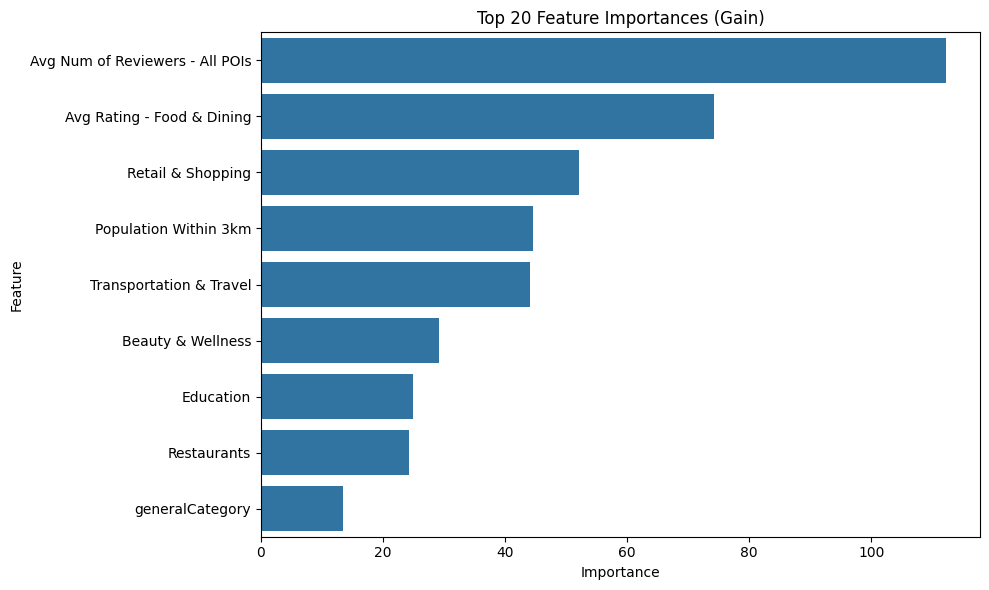

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(20), x='Importance', y='Feature')
plt.title('Top 20 Feature Importances (Gain)')
plt.tight_layout()
plt.show()


LambdaMART (Good results)

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer, MinMaxScaler
from sklearn.metrics import ndcg_score
import lightgbm as lgb

def compute_nsd(true_labels, pred_labels, k=10):
    """ Compute Normalized Symmetric Difference at k (nSD@k) """
    true_top_k = set(np.argsort(true_labels)[::-1][:k])  # Get the indices of the top k true labels
    pred_top_k = set(np.argsort(pred_labels)[::-1][:k])  # Get the indices of the top k predicted labels
    symmetric_diff = true_top_k.symmetric_difference(pred_top_k)  # Compute symmetric difference
    return len(symmetric_diff) / (2 * k)  # Normalize by 2*k


# ---- 1. Load data ----
df = pd.read_csv("../../Cleaned Data/Cleaned_Data_LastVersion.csv")
drop_columns = ['Business ID', 'Name', 'Category', 'Rating', 'Google Place ID', 'Business Status',
                'Cluster', 'Distance (m)', 'Avg Rating - Business Type', 'Competition - Business Type/Area', 
                'Competition - Food & Dining/Area', 'Competition - Business Type/POI Density', 
                'Competition - Food & Dining/related POIs', 'Competition - Business Type/related POIs',
                'Google Rating', 'Business Name', 'Popularity', 'Latitude', 'Longitude', 
                'Total Num of Reviewers - Food & Dining', 'Total Num of Reviewers - All POIs', 
                'Avg_NumOfReviewers - Food & Dining','Avg_NumOfReviewers_SameCategory', 
                'Total Num of Reviewers - Food & Dining','Population Within 1km', 
                'Population Within 2km', 'Popularity', 'POI Density',
                #here the new dropped ones
                'Avg Num of Reviewers - All POIs' , 'Retail & Shopping', 'Beauty & Wellness', 'Avg Rating - Food & Dining', 
                'Transportation & Travel', 'Health']
df.drop(columns=drop_columns, inplace=True, errors='ignore')

# ---- 2. Feature columns ----
feature_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
feature_cols = [col for col in feature_cols if col != 'Number of Reviewers']
df = df.dropna(subset=['Number of Reviewers'] + feature_cols).reset_index(drop=True)

# ---- 3. Split districts into train/test ----
districts = df['District'].unique()
train_districts, test_districts = train_test_split(districts, test_size=0.2, random_state=42)
train_df = df[df['District'].isin(train_districts)].reset_index(drop=True)
test_df = df[df['District'].isin(test_districts)].reset_index(drop=True)

# ---- 4. Relevance score binning ----
y_train = train_df['Number of Reviewers']
y_test = test_df['Number of Reviewers']
y_train_relevance = pd.qcut(y_train, q=5, labels=False, duplicates='drop')
y_test_relevance = pd.qcut(y_test, q=5, labels=False, duplicates='drop')

# ---- 5. Feature transformation ----
pt = PowerTransformer(method='yeo-johnson', standardize=False)
scaler = MinMaxScaler()
X_train_base = pt.fit_transform(train_df[feature_cols])
X_train_base = scaler.fit_transform(X_train_base)
X_test_base = pt.transform(test_df[feature_cols])
X_test_base = scaler.transform(X_test_base)

train_groups = train_df.groupby('District').size().values
test_groups = test_df.groupby('District').size().values

# ---- 6. Grid Search ----
param_grid = {
    'num_leaves': [15, 31, 63],
    'learning_rate': [0.01, 0.05, 0.1],
}

best_score = -1
best_model = None
best_params = None

for leaves in param_grid['num_leaves']:
    for lr in param_grid['learning_rate']:
        params = {
            'objective': 'lambdarank',
            'metric': 'ndcg',
            'boosting_type': 'gbdt',
            'num_leaves': leaves,
            'learning_rate': lr,
            'verbosity': -1
        }

        train_data = lgb.Dataset(X_train_base, label=y_train_relevance, group=train_groups)
        test_data = lgb.Dataset(X_test_base, label=y_test_relevance, group=test_groups)

        model = lgb.train(
            params,
            train_set=train_data,
            valid_sets=[test_data],
            num_boost_round=100,
            callbacks=[lgb.early_stopping(stopping_rounds=10)],
        )

        y_pred = model.predict(X_test_base)
        ndcg = ndcg_score([y_test_relevance], [y_pred], k=10)
        nsd_at_10 = compute_nsd(y_test_relevance, y_pred, k=10)
        print(f"[Grid] num_leaves={leaves}, learning_rate={lr} -> nDCG@10: {ndcg:.3f} , nSD@10: {nsd_at_10:.3f}")

        if ndcg > best_score:
            best_score = ndcg
            best_params = params
            best_model = model

print("\nBest Grid Params:", best_params)
print("Best nDCG@10 from Grid Search:", best_score)

# ---- 7. RFE (Recursive Feature Elimination) ----
print("\n--- RFE: Feature Elimination Evaluation ---")
feature_ndcg_scores = {}

for feature in feature_cols:
    selected_features = [f for f in feature_cols if f != feature]
    
    X_train_temp = scaler.fit_transform(pt.fit_transform(train_df[selected_features]))
    X_test_temp = scaler.transform(pt.transform(test_df[selected_features]))

    train_data = lgb.Dataset(X_train_temp, label=y_train_relevance, group=train_groups)
    test_data = lgb.Dataset(X_test_temp, label=y_test_relevance, group=test_groups)

    model = lgb.train(
        best_params,
        train_set=train_data,
        valid_sets=[test_data],
        num_boost_round=100,
        callbacks=[lgb.early_stopping(stopping_rounds=10)],
    )

    y_pred = model.predict(X_test_temp)
    ndcg = ndcg_score([y_test_relevance], [y_pred], k=10)
    nsd_at_10 = compute_nsd(y_test_relevance, y_pred, k=10)
    feature_ndcg_scores[feature] = ndcg

    print(f"[RFE] Removed '{feature}' -> nDCG@10: {ndcg:.3f}, nSD@10: {nsd_at_10:.3f}")
    print(selected_features)

sorted_features = sorted(feature_ndcg_scores.items(), key=lambda x: x[1])
print("\nFeature Ranking (least useful first):")
for f, score in sorted_features:
    print(f"{f}: {score:.3f}")


Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[1]	valid_0's ndcg@1: 0.553846	valid_0's ndcg@2: 0.62745	valid_0's ndcg@3: 0.626839	valid_0's ndcg@4: 0.646716	valid_0's ndcg@5: 0.650342
[Grid] num_leaves=15, learning_rate=0.01 -> nDCG@10: 0.614 , nSD@10: 1.000
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[6]	valid_0's ndcg@1: 0.543956	valid_0's ndcg@2: 0.652909	valid_0's ndcg@3: 0.63932	valid_0's ndcg@4: 0.621972	valid_0's ndcg@5: 0.63396
[Grid] num_leaves=15, learning_rate=0.05 -> nDCG@10: 0.588 , nSD@10: 0.900
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[2]	valid_0's ndcg@1: 0.565201	valid_0's ndcg@2: 0.652632	valid_0's ndcg@3: 0.691066	valid_0's ndcg@4: 0.699115	valid_0's ndcg@5: 0.711501
[Grid] num_leaves=15, learning_rate=0.1 -> nDCG@10: 0.638 , nSD@10: 1.000
Training until validation scores don't improve for 10 rounds
Early stoppin

In [216]:
from sklearn.preprocessing import PowerTransformer, MinMaxScaler

# Split combined_df into 80% train and 20% test
combined_df_train, combined_df_test = train_test_split(
    com_df,
    test_size=0.2,
    random_state=42,  # for reproducibility
    shuffle=True      # ensure data is shuffled before splitting
)


# Initialize PowerTransformer for X
pt = PowerTransformer(method='yeo-johnson', standardize=False)  # Set standardize=False since we'll use MinMaxScaler next
scaler = MinMaxScaler()

# Fit on train and apply to both train and test
X_train_transformed = scaler.fit_transform(pt.fit_transform(X_train))
X_test_transformed = scaler.transform(pt.transform(X_test))

# Reshape y to 2D arrays (required by sklearn scalers)
y_train_reshaped = y_train.values.reshape(-1, 1)
y_test_reshaped = y_test.reshape(-1, 1)

# Initialize separate transformers for y
pt_y = PowerTransformer(method='yeo-johnson', standardize=False)
scaler_y = MinMaxScaler()

# Fit on training target and transform both y_train and y_test
y_train_transformed = scaler_y.fit_transform(pt_y.fit_transform(y_train_reshaped)).ravel()
y_test_transformed = scaler_y.transform(pt_y.transform(y_test_reshaped)).ravel()

import lightgbm as lgb
from lightgbm import early_stopping

# Create LightGBM datasets
train_data = lgb.Dataset(X_train_transformed, label=y_train_transformed, group=group_sizes)
test_data = lgb.Dataset(X_test_transformed, label=y_test_transformed, group=group_sizes)

# Define the LambdaMART parameters
params = {
    'objective': 'lambdarank',
    'metric': 'ndcg',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'verbosity': -1
}


model = lgb.train(
    params,
    train_set=train_data,
    valid_sets=[test_data],
    num_boost_round=100,
    callbacks=[early_stopping(stopping_rounds=10)]
)


# Predict scores (rankings)
y_pred = model.predict(X_test)

# Evaluate ranking performance using nDCG (Normalized Discounted Cumulative Gain)
from sklearn.metrics import ndcg_score

true_ranks = y_test_transformed.values.reshape(1, -1)
pred_ranks = y_pred.reshape(1, -1)

ndcg = ndcg_score(true_ranks, pred_ranks, k=10)
print(f"nDCG@10: {ndcg:.3f}")

true_ranks = y_test_transformed.argsort()[::-1]     # Highest true values first
pred_ranks = y_pred.argsort()[::-1]     # Model's top predictions

k = 10
true_top_k = set(true_ranks[:k])
pred_top_k = set(pred_ranks[:k])

symmetric_diff = true_top_k.symmetric_difference(pred_top_k)
nSD = len(symmetric_diff) / (2 * k)

print(f"nSD@{k}: {nSD:.3f}")




In [223]:
import lightgbm as lgb
from lightgbm import early_stopping

# Create LightGBM datasets
train_data = lgb.Dataset(X_train_transformed, label=y_train_transformed, group=group_sizes)
test_data = lgb.Dataset(X_test_transformed, label=y_test_transformed, group=group_sizes)

# Define the LambdaMART parameters
params = {
    'objective': 'lambdarank',
    'metric': 'ndcg',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'verbosity': -1
}


model = lgb.train(
    params,
    train_set=train_data,
    valid_sets=[test_data],
    num_boost_round=100,
    callbacks=[early_stopping(stopping_rounds=10)]
)


# Predict scores (rankings)
y_pred = model.predict(X_test)

# Evaluate ranking performance using nDCG (Normalized Discounted Cumulative Gain)
from sklearn.metrics import ndcg_score

true_ranks = y_test_transformed.values.reshape(1, -1)
pred_ranks = y_pred.reshape(1, -1)

ndcg = ndcg_score(true_ranks, pred_ranks, k=10)
print(f"nDCG@10: {ndcg:.3f}")

true_ranks = y_test_transformed.argsort()[::-1]     # Highest true values first
pred_ranks = y_pred.argsort()[::-1]     # Model's top predictions

k = 10
true_top_k = set(true_ranks[:k])
pred_top_k = set(pred_ranks[:k])

symmetric_diff = true_top_k.symmetric_difference(pred_top_k)
nSD = len(symmetric_diff) / (2 * k)

print(f"nSD@{k}: {nSD:.3f}")



LightGBMError: Sum of query counts (1488) differs from the length of #data (1863)

In [374]:
train_groups = [len(X_train_transformed)]
test_groups = [len(X_test_transformed)]

In [377]:
import lightgbm as lgb
import numpy as np
from sklearn.metrics import ndcg_score, mean_squared_error, r2_score, mean_absolute_error
from lightgbm import early_stopping

# Create LightGBM datasets
train_data = lgb.Dataset(X_train_transformed, label=y_train, group=train_groups)
test_data = lgb.Dataset(X_test_transformed, label=y_test, group=test_groups)

# Define parameters
params = {
    'objective': 'lambdarank',
    'metric': 'ndcg',
    'boosting': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'verbosity': -1
}


# Bin into 0 (low), 1 (medium), 2 (high) relevance
y_train = pd.qcut(y_train, q=3, labels=False)
y_test = pd.qcut(y_test, q=3, labels=False)

# Grouping
train_groups = X_train_group_col.value_counts().sort_index().values
test_groups = X_test_group_col.value_counts().sort_index().values

# Train model
model = lgb.train(
    params,
    train_data,
    valid_sets=[test_data],
    num_boost_round=100,
    callbacks=[early_stopping(stopping_rounds=10)]
)

# Predict scores
y_pred = model.predict(X_test_transformed)

# y_pred is your model's prediction (on transformed scale)
# reshape to 2D for inverse_transform and overwrite y_pred 
y_pred = pt_y.inverse_transform(scaler_y.inverse_transform(y_pred.reshape(-1, 1))).ravel()

# Regression metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Ranking metrics
k = 10
true_ranks = y_test.argsort()[::-1]
pred_ranks = y_pred.argsort()[::-1]

true_relevance = np.expand_dims(y_test, axis=0)
predicted_scores = np.expand_dims(y_pred, axis=0)

ndcg = ndcg_score(true_relevance, predicted_scores, k=k)
nSD = len(set(true_ranks[:k]).symmetric_difference(set(pred_ranks[:k]))) / (2 * k)

# Print results
print(f"R² Score:   {r2:.3f}")
print(f"MSE:        {mse:.3f}")
print(f"MAE:        {mae:.3f}")
print(f"nDCG@{k}:   {ndcg:.3f}")
print(f"nSD@{k}:    {nSD:.3f}")


NameError: name 'X_train_group_col' is not defined